# POSTC Complaint Data Analysis
**Massachusetts Police Oversight — Dankoff PRR Merged Dataset**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

# ── style ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.edgecolor':   '#999',
    'axes.labelcolor':  '#333',
    'text.color':       '#333',
    'xtick.color':      '#555',
    'ytick.color':      '#555',
    'grid.color':       '#e0e0e0',
    'grid.linestyle':   '--',
    'legend.facecolor': 'white',
    'legend.edgecolor': '#ccc',
    'font.family':      'serif',
    'font.size':        11,
})

PALETTE = {
    'Closed':                                      '#2563eb',
    'No Action - No investigation recommended':    '#ef4444',
    'No Action - Not within POSTC mandate':        '#f97316',
    'No Action - Insufficient Data':               '#eab308',
    'No Action - Duplicate':                       '#6b7280',
}
CERT_PALETTE = {
    'Certified':                    '#2563eb',
    'Certified/SRO':                '#6366f1',
    'Expired':                      '#f97316',
    'Restricted':                   '#ef4444',
    'Further Certification Review': '#eab308',
    'Conditionally Certified':      '#a3a3a3',
    'Decertified':                  '#7f1d1d',
    'Unknown':                      '#374151',
}

def pct(n, total):
    return f"{n} ({n/total:.1%})"

def section(title):
    print(f"\n{'='*60}\n  {title}\n{'='*60}")

def subsection(title):
    print(f"\n── {title} ──")

CSV_PATH = '../data/Dankoff_PRR_Merged.csv'   
print('Setup complete.')

Setup complete.


## 0. Load & Clean

In [2]:
df = pd.read_csv(CSV_PATH)
df['CREATEDDATE']     = pd.to_datetime(df['CREATEDDATE'], errors='coerce')
df['COMPLAINTNUMBER'] = pd.to_numeric(df['COMPLAINTNUMBER'], errors='coerce')
df['CERTIFICATIONSTATUS'] = df['CERTIFICATIONSTATUS'].str.strip()
df['year']  = df['CREATEDDATE'].dt.year
df['month'] = df['CREATEDDATE'].dt.to_period('M')

allegation_flags = ['Improper Use of Weapon','Excessive Force','Serious Injury','Unprofessionalism','Other']
discrimination_flags = ['No Discrimination claimed','bias','racial bias','ethnicity',
                        'gender identity','sexual orientation','age','religion',
                        'mental or physical disability','immigration status','socioeconomic level']

for col in allegation_flags + discrimination_flags:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

disc_cols = [c for c in discrimination_flags if c != 'No Discrimination claimed' and c in df.columns]
df['any_discrimination'] = (df[disc_cols].sum(axis=1) > 0).astype(int)

# dedup views
unique_cases   = df.drop_duplicates(subset='COMPLAINTNUMBER').copy()
unique_officers = df.drop_duplicates(subset='COMPLAINTPARTICIPANTNUMBER').copy()

total_rows     = len(df)
total_cases    = unique_cases['COMPLAINTNUMBER'].nunique()
total_officers = unique_officers['COMPLAINTPARTICIPANTNUMBER'].nunique()

print(f'Rows: {total_rows} | Unique complaints: {total_cases} | Unique officers: {total_officers}')
print(f'Date range: {df["CREATEDDATE"].min().date()} → {df["CREATEDDATE"].max().date()}')
df.head(3)

Rows: 378 | Unique complaints: 266 | Unique officers: 290
Date range: 2023-02-03 → 2025-12-08


,CREATEDDATE,COMPLAINTNUMBER,Allegations,REPORTINGAGENCY,COMPLAINTPARTICIPANTNUMBER,OFFICERRANK,TITLE,GENDER,RACE,CERTIFICATIONSTATUS,...,gender identity,sexual orientation,age,religion,mental or physical disability,immigration status,socioeconomic level,year,month,any_discrimination
0,2023-02-03,49.0,0,Boston Police Department,P-00000066,Sergeant,Sergeant,NaN,NaN,Certified,...,0,0,0,0,0,0,0,2023,2023-02,0
1,2023-02-03,49.0,0,NaN,P-00000065,NaN,Sergeant,NaN,NaN,Restricted,...,0,0,0,0,0,0,0,2023,2023-02,0
2,2023-02-03,49.0,0,Leominster Police Department,P-00000064,Captain,Captain,Male,White,Certified,...,0,0,0,0,0,0,0,2023,2023-02,0


## 1. Dataset Overview


  DATASET OVERVIEW
  Total rows        : 378
  Unique complaints : 266
  Unique officers   : 290
  Unique agencies   : 103
  Date range        : 2023-02-03 → 2025-12-08


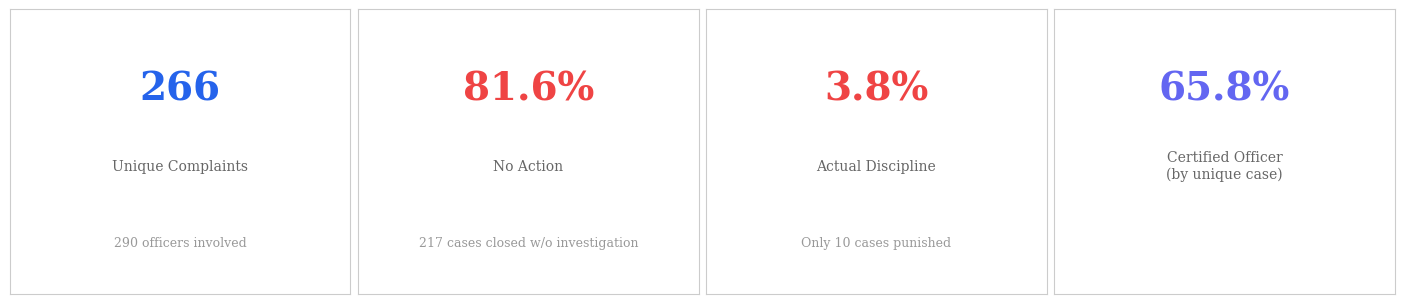

In [3]:
section('DATASET OVERVIEW')
print(f'  Total rows        : {total_rows}')
print(f'  Unique complaints : {total_cases}')
print(f'  Unique officers   : {total_officers}')
print(f'  Unique agencies   : {df["REPORTINGAGENCY"].nunique()}')
print(f'  Date range        : {df["CREATEDDATE"].min().date()} → {df["CREATEDDATE"].max().date()}')

# scorecard
no_action_n  = unique_cases['STATUS'].str.startswith('No Action', na=False).sum()
closed_n     = (unique_cases['STATUS'] == 'Closed').sum()
actual_disc  = unique_cases[
    unique_cases['Discipline'].notna() &
    ~unique_cases['Discipline'].isin(['No Discipline Imposed', 'Not Applicable'])
]

cards = [
    ('Unique Complaints', f'{total_cases}', f'{total_officers} officers involved'),
    ('No Action', f'{no_action_n/total_cases:.1%}', f'{no_action_n} cases closed w/o investigation'),
    ('Actual Discipline', f'{len(actual_disc)/total_cases:.1%}', f'Only {len(actual_disc)} cases punished'),
    ('Certified Officer\n(by unique case)', f'{(unique_cases["CERTIFICATIONSTATUS"]=="Certified").sum()/total_cases:.1%}', ''),
]

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
fig.patch.set_facecolor('white')
colors = ['#2563eb','#ef4444','#ef4444','#6366f1']
for ax, (label, val, sub), c in zip(axes, cards, colors):
    ax.set_facecolor('white')
    for spine in ax.spines.values(): spine.set_edgecolor('#ccc')
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.5, 0.72, val,   ha='center', va='center', fontsize=28, fontweight='bold', color=c,    transform=ax.transAxes)
    ax.text(0.5, 0.45, label, ha='center', va='center', fontsize=10, color='#666',               transform=ax.transAxes)
    ax.text(0.5, 0.18, sub,   ha='center', va='center', fontsize=9,  color='#999',               transform=ax.transAxes)
plt.tight_layout(pad=0.5)
plt.show()

## 2. Certification Status


  CERTIFICATION STATUS

── By unique officer ──
  Certified: 260 (89.7%)
  Certified/SRO: 14 (4.8%)
  Expired: 6 (2.1%)
  Restricted: 5 (1.7%)
  nan: 2 (0.7%)
  Further Certification Review: 2 (0.7%)
  Decertified: 1 (0.3%)
  Conditionally Certified: 1 (0.3%)

── By unique complaint ──
  Certified: 175 (65.8%)
  nan: 70 (26.3%)
  Certified/SRO: 11 (4.1%)
  Expired: 4 (1.5%)
  Restricted: 2 (0.8%)
  Further Certification Review: 2 (0.8%)
  Decertified: 1 (0.4%)
  Conditionally Certified: 1 (0.4%)

── Raw rows (no dedup) ──
  Certified: 268 (70.9%)
  nan: 71 (18.8%)
  Certified/SRO: 24 (6.3%)
  Expired: 6 (1.6%)
  Restricted: 5 (1.3%)
  Further Certification Review: 2 (0.5%)
  Decertified: 1 (0.3%)
  Conditionally Certified: 1 (0.3%)


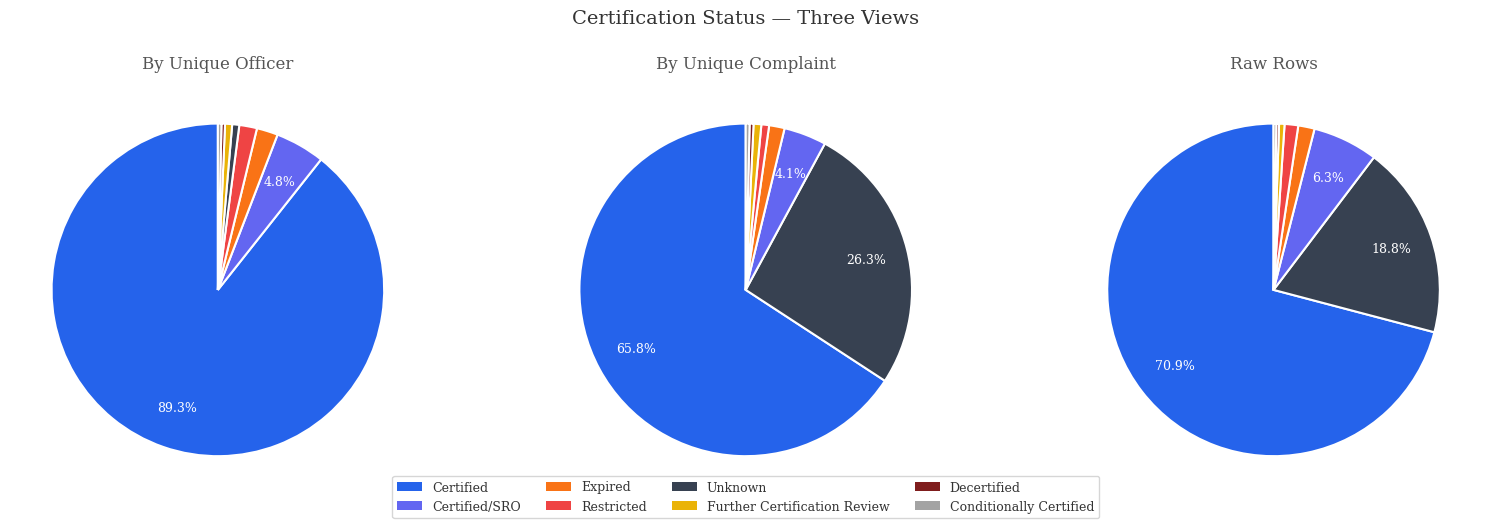

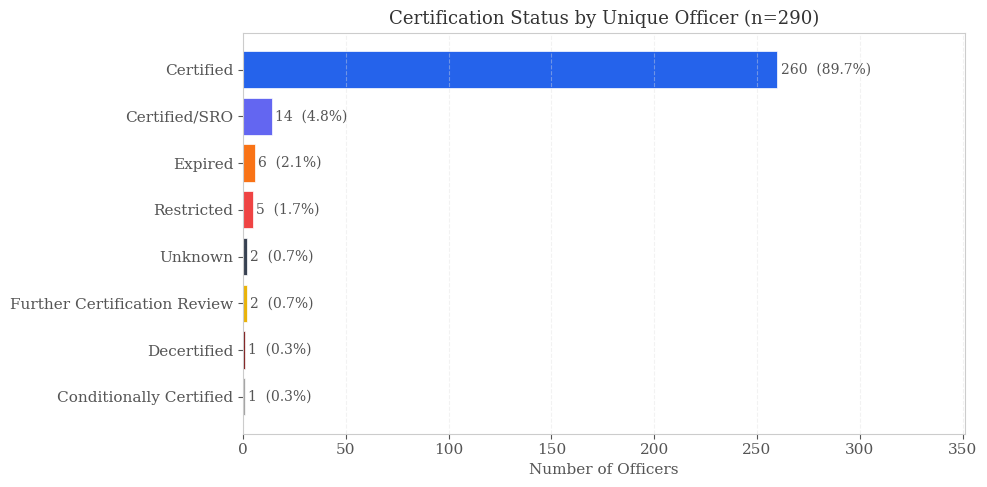

In [22]:
section('CERTIFICATION STATUS')

cert_officer  = unique_officers['CERTIFICATIONSTATUS'].value_counts(dropna=False)
cert_case     = unique_cases['CERTIFICATIONSTATUS'].value_counts(dropna=False)
cert_raw      = df['CERTIFICATIONSTATUS'].value_counts(dropna=False)

subsection('By unique officer')
for k,v in cert_officer.items(): print(f'  {k}: {pct(v, total_officers)}')
subsection('By unique complaint')
for k,v in cert_case.items():   print(f'  {k}: {pct(v, total_cases)}')
subsection('Raw rows (no dedup)')
for k,v in cert_raw.items():    print(f'  {k}: {pct(v, total_rows)}')

# chart: 3-way comparison
labels = [k if pd.notna(k) else 'Unknown' for k in cert_officer.index]
colors = [CERT_PALETTE.get(l, '#374151') for l in labels]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('white')
titles = ['By Unique Officer', 'By Unique Complaint', 'Raw Rows']
datas  = [cert_officer, cert_case, cert_raw]

for ax, data, title in zip(axes, datas, titles):
    ax.set_facecolor('white')
    ax.axis('off')
    lbls = [k if pd.notna(k) else 'Unknown' for k in data.index]
    clrs = [CERT_PALETTE.get(l, '#374151') for l in lbls]
    wedges, texts, autotexts = ax.pie(
        data.values, labels=None, colors=clrs,
        autopct=lambda p: f'{p:.1f}%' if p > 3 else '',
        pctdistance=0.75, startangle=90,
        wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'}
    )
    for at in autotexts: at.set_color('white'); at.set_fontsize(9)
    ax.set_title(title, color='#555', fontsize=12, pad=10)

# legend
from matplotlib.patches import Patch
legend_els = [Patch(facecolor=CERT_PALETTE.get(l,'#374151'), label=l) for l in labels]
fig.legend(handles=legend_els, loc='lower center', ncol=4, fontsize=9,
           facecolor='white', edgecolor='#ccc', labelcolor='#333', bbox_to_anchor=(0.5,-0.02))
fig.suptitle('Certification Status — Three Views', color='#333', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Certification Status by Unique Officer — Bar Chart ──────────────
labels_officer = [k if pd.notna(k) else 'Unknown' for k in cert_officer.index]
values_officer = cert_officer.values
colors_officer = [CERT_PALETTE.get(l, '#374151') for l in labels_officer]
pcts_officer   = values_officer / total_officers * 100

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

bars = ax.barh(labels_officer[::-1], values_officer[::-1],
               color=colors_officer[::-1], edgecolor='white', linewidth=0.5)
for bar, val, pct_val in zip(bars, values_officer[::-1], pcts_officer[::-1]):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height() / 2,
            f'{val}  ({pct_val:.1f}%)', va='center', color='#555', fontsize=10)

ax.set_xlabel('Number of Officers', color='#555')
ax.set_title('Certification Status by Unique Officer (n=290)', color='#333', fontsize=13)
ax.set_xlim(0, values_officer.max() * 1.35)
ax.grid(axis='x', alpha=0.4)
ax.tick_params(colors='#555')
for spine in ax.spines.values(): spine.set_edgecolor('#ccc')

plt.tight_layout()
plt.show()

## 3. Case Status


  CASE STATUS (unique complaints)
  No Action - Not within POSTC mandate: 84 (31.6%)
  No Action - No investigation recommended: 83 (31.2%)
  Closed: 49 (18.4%)
  No Action - Insufficient Data: 35 (13.2%)
  No Action - Duplicate: 15 (5.6%)

  → No Action: 217 (81.6%)


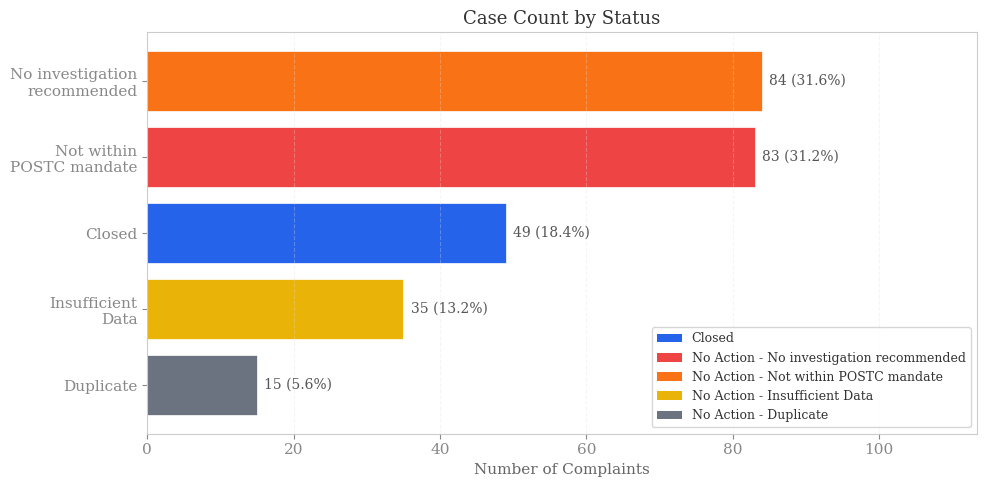

In [28]:
section('CASE STATUS (unique complaints)')
status_counts = unique_cases['STATUS'].value_counts(dropna=False)
for k,v in status_counts.items(): print(f'  {k}: {pct(v, total_cases)}')
print(f'\n  → No Action: {pct(no_action_n, total_cases)}')

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

short_labels = ['No investigation\nrecommended','Not within\nPOSTC mandate','Closed','Insufficient\nData','Duplicate']
bars = ax.barh(short_labels[::-1], status_counts.values[::-1],
               color=[PALETTE.get(k,'#555') for k in status_counts.index[::-1]],
               edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, status_counts.values[::-1]):
    ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
            f'{val} ({val/total_cases:.1%})', va='center', color='#555', fontsize=10)
ax.set_xlabel('Number of Complaints', color='#666')
ax.set_title('Case Count by Status', color='#333', fontsize=13)
ax.set_xlim(0, status_counts.max()*1.35)
ax.grid(axis='x', alpha=0.3)
ax.tick_params(colors='#888')
for spine in ax.spines.values(): spine.set_edgecolor('#ccc')

legend_els = [Patch(facecolor=PALETTE[k], label=k) for k in PALETTE]
ax.legend(handles=legend_els, loc='lower right', fontsize=9,
          facecolor='white', edgecolor='#ccc', labelcolor='#333')
plt.tight_layout()
plt.show()

## 4. Discipline


  DISCIPLINE (unique complaints)
  nan: 231 (86.8%)
  No Discipline Imposed: 23 (8.6%)
  Not Applicable: 2 (0.8%)
  Last Chance Agreement,Suspension, 1-5 days: 1 (0.4%)
  Resigned/Retired in Lieu of Discipline: 1 (0.4%)
  Retraining: 1 (0.4%)
  Written Reprimand,Retraining: 1 (0.4%)
  Written Warning or Letter of Counseling: 1 (0.4%)
  Other: 1 (0.4%)
  Suspension, 1-5 days,Demotion: 1 (0.4%)
  Pending: 1 (0.4%)
  Termination or similar: 1 (0.4%)
  Other,Retraining: 1 (0.4%)

  → Actual discipline (excl. NaN·No Discipline·Not Applicable): 10 (3.8%)


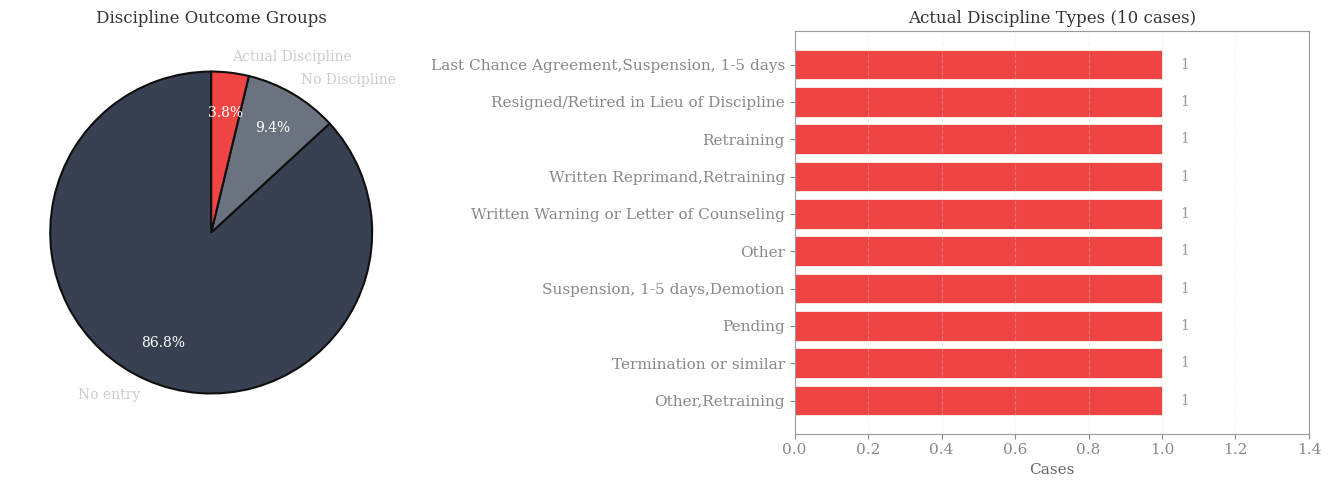

In [6]:
section('DISCIPLINE (unique complaints)')
disc = unique_cases['Discipline'].value_counts(dropna=False)
for k,v in disc.items(): print(f'  {k}: {pct(v, total_cases)}')
print(f'\n  → Actual discipline (excl. NaN·No Discipline·Not Applicable): {pct(len(actual_disc), total_cases)}')

# group: None / No Discipline / Actual
def disc_group(d):
    if pd.isna(d): return 'No entry'
    if d in ['No Discipline Imposed','Not Applicable']: return 'No Discipline'
    return 'Actual Discipline'

unique_cases['disc_group'] = unique_cases['Discipline'].apply(disc_group)
dg = unique_cases['disc_group'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

# grouped pie
ax1.set_facecolor('white'); ax1.axis('off')
dg_colors = {'No entry':'#374151','No Discipline':'#6b7280','Actual Discipline':'#ef4444'}
wedges, _, autotexts = ax1.pie(
    dg.values, labels=dg.index, colors=[dg_colors[k] for k in dg.index],
    autopct='%1.1f%%', pctdistance=0.75, startangle=90,
    wedgeprops={'linewidth':1.5,'edgecolor':'#0f0f0f'},
    textprops={'color':'#ccc','fontsize':10}
)
for at in autotexts: at.set_color('white'); at.set_fontsize(10)
ax1.set_title('Discipline Outcome Groups', color='#333', fontsize=12)

# actual discipline breakdown
actual_types = actual_disc['Discipline'].value_counts()
ax2.set_facecolor('white')
bars = ax2.barh(actual_types.index[::-1], actual_types.values[::-1],
                color='#ef4444', edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, actual_types.values[::-1]):
    ax2.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
             str(val), va='center', color='#999', fontsize=10)
ax2.set_xlabel('Cases', color='#666')
ax2.set_title('Actual Discipline Types (10 cases)', color='#333', fontsize=12)
ax2.set_xlim(0, actual_types.max()*1.4)
ax2.grid(axis='x', alpha=0.3)
ax2.tick_params(colors='#888')

plt.tight_layout()
plt.show()

## 5. Certification × Case Status Crosstab


  CERTIFICATION × CASE STATUS
STATUS                        Closed  No Action - Duplicate  No Action - Insufficient Data  No Action - No investigation recommended  No Action - Not within POSTC mandate  All
CERTIFICATIONSTATUS                                                                                                                                                            
Certified                         43                      9                             17                                        68                                    38  175
Certified/SRO                      0                      1                              2                                         5                                     3   11
Conditionally Certified            0                      0                              0                                         0                                     1    1
Decertified                        1                      0                              

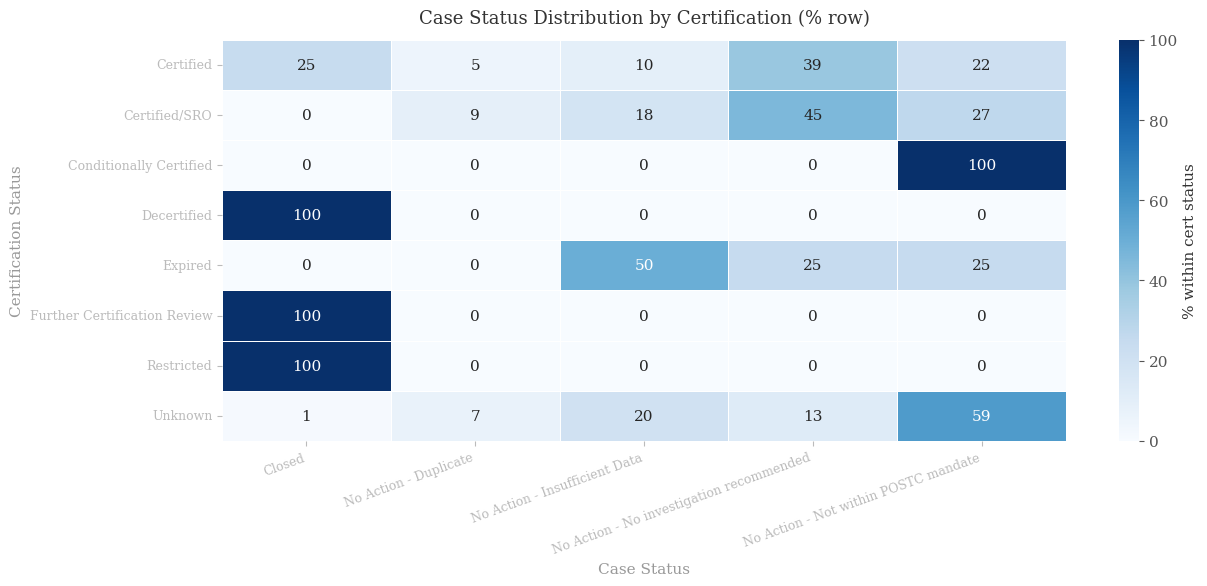


Restricted/Decertified officer = 100% Closed


In [7]:
section('CERTIFICATION × CASE STATUS')
uc = unique_cases.copy()
uc['CERTIFICATIONSTATUS'] = uc['CERTIFICATIONSTATUS'].fillna('Unknown')
cross = pd.crosstab(uc['CERTIFICATIONSTATUS'], uc['STATUS'], margins=True)
print(cross.to_string())

# heatmap (exclude All margin)
cross_pct = cross.drop('All').drop(columns='All').div(cross.drop('All').drop(columns='All').sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

cmap = sns.color_palette(['#1a1a1a','#1e3a5f','#2563eb','#1d4ed8'], as_cmap=True)
sns.heatmap(cross_pct, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label':'% within cert status'},
            ax=ax)

ax.set_title('Case Status Distribution by Certification (% row)', color='#333', fontsize=13, pad=12)
ax.set_xlabel('Case Status', color='#999')
ax.set_ylabel('Certification Status', color='#999')
ax.tick_params(colors='#bbb', labelsize=9)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

print('\nRestricted/Decertified officer = 100% Closed')

## 6. Officer Title / Rank


  OFFICER TITLE (unique officers)
  Patrol Officer: 139 (47.9%)
  Sergeant: 45 (15.5%)
  Chief: 17 (5.9%)
  Trooper: 15 (5.2%)
  Police Officer: 13 (4.5%)
  Lieutenant: 11 (3.8%)
  Detective: 8 (2.8%)
  Officer: 7 (2.4%)
  Deputy Chief of Police: 5 (1.7%)
  Deputy Chief: 4 (1.4%)
  Captain: 3 (1.0%)
  Lieutenant,  Lead IA Investigator: 3 (1.0%)
  Detective Sergeant: 3 (1.0%)
  Special Police Officer: 2 (0.7%)
  SRO: 2 (0.7%)
  Det. Sergeant: 2 (0.7%)
  Detective Lieutenant: 2 (0.7%)
  Admin: 1 (0.3%)
  Lieutenant Commander: 1 (0.3%)
  Det. Lieutenant: 1 (0.3%)
  Reserve Police Officer: 1 (0.3%)
  Special State Police Officer: 1 (0.3%)
  Sergeant/SRO: 1 (0.3%)
  New Officer: 1 (0.3%)
  Deputy Sheriff: 1 (0.3%)

── Title × Status (unique complaints) ──
STATUS                             Closed  No Action - Duplicate  No Action - Insufficient Data  No Action - No investigation recommended  No Action - Not within POSTC mandate
TITLE                                                         

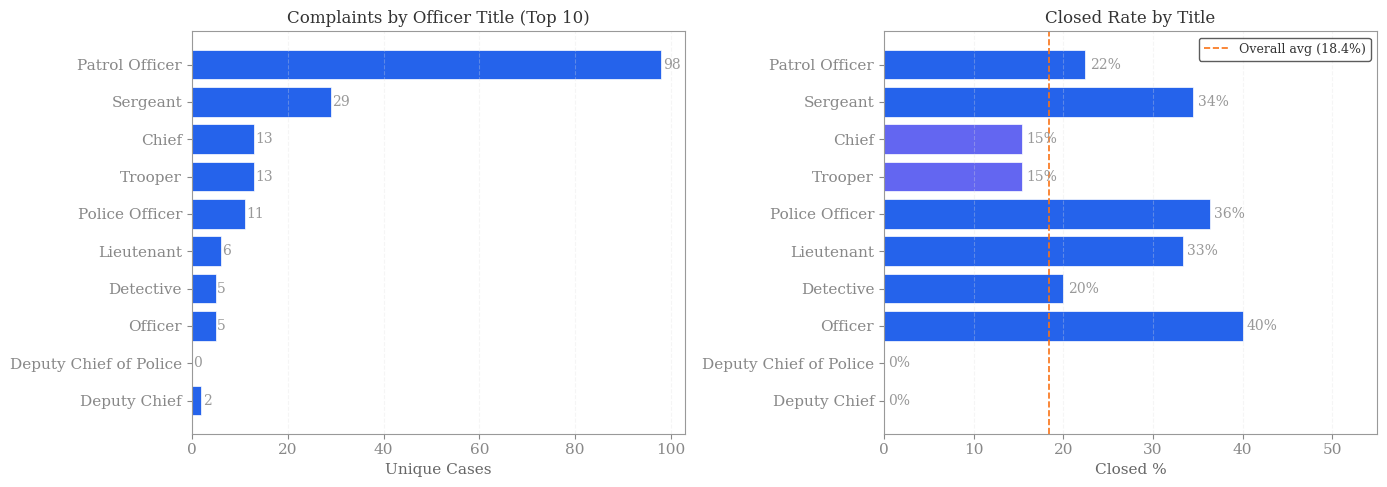

In [8]:
section('OFFICER TITLE (unique officers)')
title_counts = unique_officers['TITLE'].value_counts(dropna=True)
for k,v in title_counts.items(): print(f'  {k}: {pct(v, total_officers)}')

subsection('Title × Status (unique complaints)')
cross_title = pd.crosstab(
    unique_cases['TITLE'].fillna('Unknown'),
    unique_cases['STATUS']
)
print(cross_title.to_string())

# chart: top titles + closed rate
top_titles = title_counts.head(10).index
title_closed = []
for t in top_titles:
    sub = unique_cases[unique_cases['TITLE'] == t]
    closed_r = (sub['STATUS'] == 'Closed').sum() / len(sub) * 100 if len(sub) > 0 else 0
    title_closed.append({'Title': t, 'Count': len(sub), 'Closed%': closed_r})
title_df = pd.DataFrame(title_closed)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

ax1.set_facecolor('white')
bars = ax1.barh(title_df['Title'][::-1], title_df['Count'][::-1],
                color='#2563eb', edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, title_df['Count'][::-1]):
    ax1.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
             str(val), va='center', color='#999', fontsize=10)
ax1.set_title('Complaints by Officer Title (Top 10)', color='#333', fontsize=12)
ax1.set_xlabel('Unique Cases', color='#666')
ax1.grid(axis='x', alpha=0.3); ax1.tick_params(colors='#888')

ax2.set_facecolor('white')
clrs2 = ['#ef4444' if v < 10 else '#2563eb' if v >= 20 else '#6366f1' for v in title_df['Closed%'][::-1]]
bars2 = ax2.barh(title_df['Title'][::-1], title_df['Closed%'][::-1],
                 color=clrs2, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars2, title_df['Closed%'][::-1]):
    ax2.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
             f'{val:.0f}%', va='center', color='#999', fontsize=10)
ax2.axvline(total_cases and closed_n/total_cases*100, color='#f97316',
            linestyle='--', linewidth=1.2, label=f'Overall avg ({closed_n/total_cases:.1%})')
ax2.set_title('Closed Rate by Title', color='#333', fontsize=12)
ax2.set_xlabel('Closed %', color='#666')
ax2.set_xlim(0, 55)
ax2.legend(fontsize=9, facecolor='white', edgecolor='#333', labelcolor='#333')
ax2.grid(axis='x', alpha=0.3); ax2.tick_params(colors='#888')

plt.tight_layout()
plt.show()

## 7. Multi-Officer Cases


  MULTI-OFFICER CASES
  Single-officer: 131 (49.2%)
  Multi-officer : 56 (21.1%)

── Distribution ──
  0 officer(s): 79 cases
  1 officer(s): 131 cases
  2 officer(s): 37 cases
  3 officer(s): 9 cases
  4 officer(s): 3 cases
  5 officer(s): 3 cases
  7 officer(s): 3 cases
  10 officer(s): 1 cases

── Top 10 by officer count ──
  Case 9052: 10 officers | Brookline Police Department | No Action - No investigation recommended
  Case 12116: 7 officers | Brockton Police Department | No Action - No investigation recommended
  Case 10845: 7 officers | Tewksbury Police Department | No Action - Insufficient Data
  Case 11062: 7 officers | Boston Police Department | No Action - No investigation recommended
  Case 12622: 5 officers | Ayer Police Department | No Action - Duplicate
  Case 12111: 5 officers | Douglas Police Department | Closed
  Case 5655: 5 officers | Billerica Police Department | Closed
  Case 6403: 4 officers | Walpole Police Department | No Action - No investigation recommended

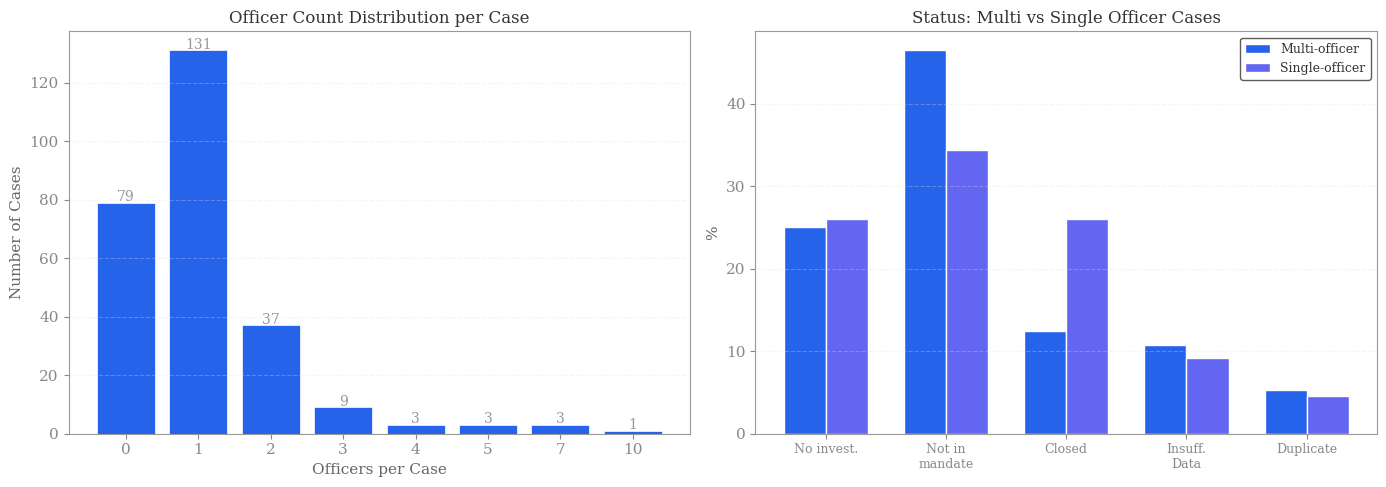

In [9]:
section('MULTI-OFFICER CASES')
officer_per_case = df.groupby('COMPLAINTNUMBER')['COMPLAINTPARTICIPANTNUMBER'].nunique()
multi  = officer_per_case[officer_per_case > 1]
single = officer_per_case[officer_per_case == 1]

print(f'  Single-officer: {pct(len(single), total_cases)}')
print(f'  Multi-officer : {pct(len(multi), total_cases)}')

subsection('Distribution')
for n, cnt in officer_per_case.value_counts().sort_index().items():
    print(f'  {n} officer(s): {cnt} cases')

subsection('Top 10 by officer count')
top10 = officer_per_case.sort_values(ascending=False).head(10)
for case, n in top10.items():
    agency = df[df['COMPLAINTNUMBER']==case]['REPORTINGAGENCY'].dropna()
    agency = agency.iloc[0] if len(agency) > 0 else 'Unknown'
    status = df[df['COMPLAINTNUMBER']==case]['STATUS'].iloc[0]
    print(f'  Case {int(case)}: {n} officers | {agency} | {status}')

# chart
opc_dist = officer_per_case.value_counts().sort_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

ax1.set_facecolor('white')
ax1.bar(opc_dist.index.astype(str), opc_dist.values,
        color='#2563eb', edgecolor='white', linewidth=0.5)
for x, y in zip(opc_dist.index, opc_dist.values):
    ax1.text(str(x), y+0.5, str(y), ha='center', color='#999', fontsize=10)
ax1.set_xlabel('Officers per Case', color='#666')
ax1.set_ylabel('Number of Cases', color='#666')
ax1.set_title('Officer Count Distribution per Case', color='#333', fontsize=12)
ax1.grid(axis='y', alpha=0.3); ax1.tick_params(colors='#888')

# multi vs single status
multi_cases_idx  = officer_per_case[officer_per_case > 1].index
single_cases_idx = officer_per_case[officer_per_case == 1].index
ms = unique_cases[unique_cases['COMPLAINTNUMBER'].isin(multi_cases_idx)]['STATUS'].value_counts(normalize=True)*100
ss = unique_cases[unique_cases['COMPLAINTNUMBER'].isin(single_cases_idx)]['STATUS'].value_counts(normalize=True)*100

ax2.set_facecolor('white')
x = np.arange(len(PALETTE))
w = 0.35
status_keys = list(PALETTE.keys())
multi_vals  = [ms.get(k,0) for k in status_keys]
single_vals = [ss.get(k,0) for k in status_keys]
ax2.bar(x-w/2, multi_vals,  w, label='Multi-officer',  color='#2563eb', edgecolor='white')
ax2.bar(x+w/2, single_vals, w, label='Single-officer', color='#6366f1', edgecolor='white')
short = ['No invest.','Not in\nmandate','Closed','Insuff.\nData','Duplicate']
ax2.set_xticks(x); ax2.set_xticklabels(short, fontsize=9)
ax2.set_ylabel('%', color='#666')
ax2.set_title('Status: Multi vs Single Officer Cases', color='#333', fontsize=12)
ax2.legend(fontsize=9, facecolor='white', edgecolor='#333', labelcolor='#333')
ax2.grid(axis='y', alpha=0.3); ax2.tick_params(colors='#888')

plt.tight_layout()
plt.show()

## 8. Allegation Type Flags


  ALLEGATION TYPE FLAGS (Sheets B/C)
  Improper Use of Weapon: 3 rows
  Excessive Force: 27 rows
  Serious Injury: 10 rows
  Unprofessionalism: 104 rows
  Other: 50 rows

Allegation × Closed rate:
                  Flag  Cases   Closed%
Improper Use of Weapon      3 33.333333
       Excessive Force     17 17.647059
        Serious Injury      8 12.500000
     Unprofessionalism     77 15.584416
                 Other     46 17.391304


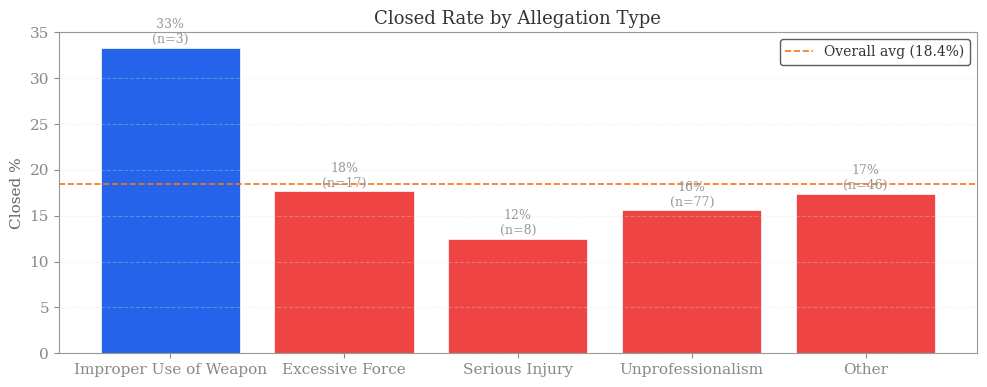

In [10]:
section('ALLEGATION TYPE FLAGS (Sheets B/C)')
avail_flags = [f for f in allegation_flags if f in df.columns]
for col in avail_flags:
    flagged = (df[col]==1).sum()
    if flagged > 0: print(f'  {col}: {flagged} rows')

# per-flag closed rate
flag_summary = []
for col in avail_flags:
    flagged_cases = df[df[col]==1]['COMPLAINTNUMBER'].unique()
    if len(flagged_cases) == 0: continue
    sub = unique_cases[unique_cases['COMPLAINTNUMBER'].isin(flagged_cases)]
    closed_r = (sub['STATUS']=='Closed').sum() / len(sub) * 100
    flag_summary.append({'Flag': col, 'Cases': len(sub), 'Closed%': closed_r})
fs_df = pd.DataFrame(flag_summary)

print('\nAllegation × Closed rate:')
print(fs_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

clrs = ['#ef4444' if v < closed_n/total_cases*100 else '#2563eb' for v in fs_df['Closed%']]
bars = ax.bar(fs_df['Flag'], fs_df['Closed%'], color=clrs, edgecolor='white', linewidth=0.5)
ax.axhline(closed_n/total_cases*100, color='#f97316', linestyle='--', linewidth=1.2,
           label=f'Overall avg ({closed_n/total_cases:.1%})')
for bar, row in zip(bars, fs_df.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{row._3:.0f}%\n(n={row.Cases})', ha='center', color='#999', fontsize=9)
ax.set_ylabel('Closed %', color='#666')
ax.set_title('Closed Rate by Allegation Type', color='#333', fontsize=13)
ax.set_ylim(0, 35)
ax.legend(fontsize=10, facecolor='white', edgecolor='#333', labelcolor='#333')
ax.grid(axis='y', alpha=0.3); ax.tick_params(colors='#888')
plt.tight_layout()
plt.show()

## 9. Discrimination Flags


  DISCRIMINATION FLAGS (Sheets D/E)
  Cases with discrimination claim    : 37
  Cases with no discrimination claim : 43

── Discrimination type breakdown ──
  bias: 2 rows
  racial bias: 27 rows
  ethnicity: 22 rows
  gender identity: 15 rows
  sexual orientation: 8 rows
  age: 10 rows
  religion: 3 rows
  mental or physical disability: 25 rows
  socioeconomic level: 14 rows

── Discrimination → Status ──
  No Action - No investigation recommended: 16 (43.2%)
  No Action - Not within POSTC mandate: 7 (18.9%)
  No Action - Insufficient Data: 7 (18.9%)
  Closed: 5 (13.5%)
  No Action - Duplicate: 2 (5.4%)

── Non-discrimination → Status ──
  No Action - Not within POSTC mandate: 77 (33.6%)
  No Action - No investigation recommended: 67 (29.3%)
  Closed: 44 (19.2%)
  No Action - Insufficient Data: 28 (12.2%)
  No Action - Duplicate: 13 (5.7%)


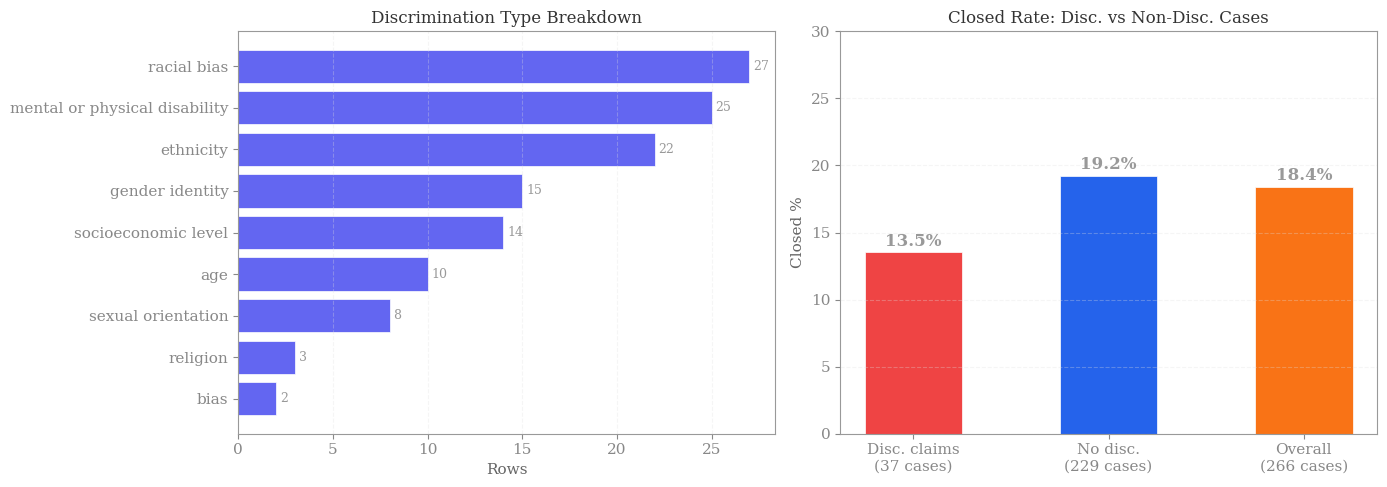


Note: Discrimination claims have a lower Closed rate — likely filtered out as outside POSTC mandate


In [11]:
section('DISCRIMINATION FLAGS (Sheets D/E)')
disc_cases_idx    = df[df['any_discrimination']==1]['COMPLAINTNUMBER'].unique()
no_disc_cases_idx = df[df['No Discrimination claimed']==1]['COMPLAINTNUMBER'].unique() if 'No Discrimination claimed' in df.columns else []

print(f'  Cases with discrimination claim    : {len(disc_cases_idx)}')
print(f'  Cases with no discrimination claim : {len(no_disc_cases_idx)}')

subsection('Discrimination type breakdown')
for col in disc_cols:
    flagged = (df[col]==1).sum()
    if flagged > 0: print(f'  {col}: {flagged} rows')

disc_sub     = unique_cases[unique_cases['COMPLAINTNUMBER'].isin(disc_cases_idx)]
non_disc_sub = unique_cases[~unique_cases['COMPLAINTNUMBER'].isin(disc_cases_idx)]

subsection('Discrimination → Status')
for k,v in disc_sub['STATUS'].value_counts().items():
    print(f'  {k}: {pct(v, len(disc_sub))}')
subsection('Non-discrimination → Status')
for k,v in non_disc_sub['STATUS'].value_counts().items():
    print(f'  {k}: {pct(v, len(non_disc_sub))}')

# chart
disc_type_counts = {col: (df[col]==1).sum() for col in disc_cols if (df[col]==1).sum()>0}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

ax1.set_facecolor('white')
sorted_dtc = dict(sorted(disc_type_counts.items(), key=lambda x: x[1]))
ax1.barh(list(sorted_dtc.keys()), list(sorted_dtc.values()),
         color='#6366f1', edgecolor='white', linewidth=0.5)
for i, (k,v) in enumerate(sorted_dtc.items()):
    ax1.text(v+0.2, i, str(v), va='center', color='#999', fontsize=9)
ax1.set_xlabel('Rows', color='#666')
ax1.set_title('Discrimination Type Breakdown', color='#333', fontsize=12)
ax1.grid(axis='x', alpha=0.3); ax1.tick_params(colors='#888')

# side-by-side closed rate
ax2.set_facecolor('white')
compare = {
    f'Disc. claims\n(37 cases)': (disc_sub['STATUS']=='Closed').sum()/len(disc_sub)*100,
    f'No disc.\n(229 cases)':    (non_disc_sub['STATUS']=='Closed').sum()/len(non_disc_sub)*100,
    f'Overall\n(266 cases)':     closed_n/total_cases*100,
}
bars = ax2.bar(compare.keys(), compare.values(),
               color=['#ef4444','#2563eb','#f97316'],
               edgecolor='white', linewidth=0.5, width=0.5)
for bar, v in zip(bars, compare.values()):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{v:.1f}%', ha='center', color='#999', fontsize=12, fontweight='bold')
ax2.set_ylabel('Closed %', color='#666')
ax2.set_title('Closed Rate: Disc. vs Non-Disc. Cases', color='#333', fontsize=12)
ax2.set_ylim(0, 30)
ax2.grid(axis='y', alpha=0.3); ax2.tick_params(colors='#888')

plt.tight_layout()
plt.show()

print('\nNote: Discrimination claims have a lower Closed rate — likely filtered out as outside POSTC mandate')

## 10. LEA Disposition vs POSTC Status

In [ ]:
section('LEA DISPOSITION × POSTC DISPOSITION × STATUS')

# ── prep ───────────────────────────────────────────────────────────
def norm_lea(val):
    v = str(val).strip()
    if v in ('0', '', 'nan'): return None
    if 'Sustained' in v and len(v.replace('Sustained','').strip(',')) == 0:
        return 'Sustained'
    if 'Sustained' in v: return 'Sustained (mixed)'
    if v == 'Exonerated': return 'Exonerated'
    if 'Exonerated' in v: return 'Exonerated (mixed)'
    if v == 'Not Sustained': return 'Not Sustained'
    if v == 'Unfounded': return 'Unfounded'
    if 'Unfounded' in v: return 'Unfounded (mixed)'
    return v

def norm_postc(val):
    v = str(val).strip()
    if v in ('0', '', 'nan'): return '(No POSTC disposition)'
    return v

uc = unique_cases.copy()
uc['lea']   = uc['LEA Disposition (Allegations)'].apply(norm_lea)
uc['postc'] = uc['POSTC Disposition (Allegations)'].apply(norm_postc)

has_lea  = uc[uc['lea'].notna()]
no_lea   = uc[uc['lea'].isna()]

print(f"Has LEA disposition : {len(has_lea)} cases")
print(f"No  LEA disposition : {len(no_lea)} cases")
print(f"\nLEA disposition breakdown:")
for k,v in has_lea['lea'].value_counts().items():
    print(f"  {k}: {v}")
print(f"\nPOSTC disposition breakdown:")
for k,v in uc['postc'].value_counts().items():
    print(f"  {k}: {v}")
print(f"\nFull flow (has LEA):")
for _, r in has_lea[['lea','postc','STATUS']].value_counts().reset_index().iterrows():
    print(f"  LEA={r['lea']:30} POSTC={r['postc']:35} STATUS={r['STATUS']}  n={r['count']}")

# ── colour maps ─────────────────────────────────────────────────────
LEA_COLORS = {
    'Sustained':           '#ef4444',
    'Sustained (mixed)':   '#f87171',
    'Exonerated':          '#2563eb',
    'Exonerated (mixed)':  '#60a5fa',
    'Not Sustained':       '#f97316',
    'Unfounded':           '#eab308',
    'Unfounded (mixed)':   '#fde047',
}
POSTC_COLORS = {
    'Accept LEA Disposition':        '#2563eb',
    'Investigated as Part of a PI':  '#6366f1',
    '(No POSTC disposition)':        '#e2e8f0',
}

# ── Figure 1: three-column distribution overview ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('white')
fig.suptitle('LEA Disposition  →  POSTC Disposition  →  STATUS', color='#333', fontsize=14, y=1.02)

# Panel 1: LEA
ax = axes[0]; ax.set_facecolor('white')
lea_vals = uc['lea'].fillna('(No LEA disposition)').value_counts()
colors_lea = [LEA_COLORS.get(k, '#94a3b8') for k in lea_vals.index]
bars = ax.barh(lea_vals.index[::-1], lea_vals.values[::-1], color=colors_lea[::-1], edgecolor='white')
for bar, v in zip(bars, lea_vals.values[::-1]):
    ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
            f'{v} ({v/total_cases:.0%})', va='center', color='#555', fontsize=9)
ax.set_title('LEA Disposition', color='#333', fontsize=12)
ax.set_xlim(0, lea_vals.max()*1.5)
ax.grid(axis='x', alpha=0.3); ax.tick_params(colors='#555', labelsize=9)
for s in ax.spines.values(): s.set_edgecolor('#ccc')

# Panel 2: POSTC
ax = axes[1]; ax.set_facecolor('white')
postc_vals = uc['postc'].value_counts()
colors_postc = [POSTC_COLORS.get(k,'#94a3b8') for k in postc_vals.index]
bars = ax.barh(postc_vals.index[::-1], postc_vals.values[::-1], color=colors_postc[::-1], edgecolor='white')
for bar, v in zip(bars, postc_vals.values[::-1]):
    ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
            f'{v} ({v/total_cases:.0%})', va='center', color='#555', fontsize=9)
ax.set_title('POSTC Disposition', color='#333', fontsize=12)
ax.set_xlim(0, postc_vals.max()*1.4)
ax.grid(axis='x', alpha=0.3); ax.tick_params(colors='#555', labelsize=9)
for s in ax.spines.values(): s.set_edgecolor('#ccc')

# Panel 3: STATUS
ax = axes[2]; ax.set_facecolor('white')
status_vals = uc['STATUS'].value_counts()
short = {
    'Closed': 'Closed',
    'No Action - No investigation recommended': 'No invest. recommended',
    'No Action - Not within POSTC mandate':     'Not within mandate',
    'No Action - Insufficient Data':            'Insufficient Data',
    'No Action - Duplicate':                    'Duplicate',
}
bars = ax.barh([short.get(k,k) for k in status_vals.index[::-1]],
               status_vals.values[::-1],
               color=[PALETTE.get(k,'#94a3b8') for k in status_vals.index[::-1]],
               edgecolor='white')
for bar, v in zip(bars, status_vals.values[::-1]):
    ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
            f'{v} ({v/total_cases:.0%})', va='center', color='#555', fontsize=9)
ax.set_title('POSTC Status', color='#333', fontsize=12)
ax.set_xlim(0, status_vals.max()*1.4)
ax.grid(axis='x', alpha=0.3); ax.tick_params(colors='#555', labelsize=9)
for s in ax.spines.values(): s.set_edgecolor('#ccc')

plt.tight_layout()
plt.show()

# ── Figure 2: flow — has LEA disposition (33 cases) ────────────────
flow = has_lea.groupby(['lea','postc','STATUS']).size().reset_index(name='n')

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')
fig.suptitle('Flow: Cases WITH LEA Disposition (n=33)  —  LEA → POSTC → STATUS',
             color='#333', fontsize=13)

lea_cats   = has_lea['lea'].value_counts().index.tolist()
postc_cats = [c for c in ['Accept LEA Disposition','Investigated as Part of a PI','(No POSTC disposition)']
              if c in has_lea['postc'].values]
status_cats = list(PALETTE.keys())

x_lea, x_postc, x_status = 0, 1, 2
y_lea   = {c: i for i, c in enumerate(lea_cats[::-1])}
y_postc = {c: i for i, c in enumerate(postc_cats[::-1])}
y_status= {c: i for i, c in enumerate([k for k in status_cats if k in has_lea['STATUS'].values][::-1])}

# scatter nodes
for c, yi in y_lea.items():
    n = (has_lea['lea'] == c).sum()
    ax.scatter(x_lea, yi, s=n*80, color=LEA_COLORS.get(c,'#94a3b8'), zorder=3)
    ax.text(x_lea-0.08, yi, f'{c}\n(n={n})', ha='right', va='center', fontsize=8.5, color='#333')

for c, yi in y_postc.items():
    n = (has_lea['postc'] == c).sum()
    ax.scatter(x_postc, yi, s=n*80, color=POSTC_COLORS.get(c,'#94a3b8'), zorder=3)
    ax.text(x_postc, yi+0.35, f'{c}\n(n={n})', ha='center', va='bottom', fontsize=8.5, color='#333')

for c, yi in y_status.items():
    n = (has_lea['STATUS'] == c).sum()
    ax.scatter(x_status, yi, s=n*80, color=PALETTE.get(c,'#94a3b8'), zorder=3)
    ax.text(x_status+0.08, yi, f'{short.get(c,c)}\n(n={n})', ha='left', va='center', fontsize=8.5, color='#333')

# draw lines
for _, row in flow.iterrows():
    if row['lea'] in y_lea and row['postc'] in y_postc:
        ax.plot([x_lea, x_postc], [y_lea[row['lea']], y_postc[row['postc']]],
                color=LEA_COLORS.get(row['lea'],'#aaa'), alpha=0.4,
                linewidth=row['n']*1.5)
    if row['postc'] in y_postc and row['STATUS'] in y_status:
        ax.plot([x_postc, x_status], [y_postc[row['postc']], y_status[row['STATUS']]],
                color=PALETTE.get(row['STATUS'],'#aaa'), alpha=0.4,
                linewidth=row['n']*1.5)

ax.set_xlim(-0.6, 2.6)
ax.set_xticks([x_lea, x_postc, x_status])
ax.set_xticklabels(['LEA Disposition', 'POSTC Disposition', 'STATUS'],
                   fontsize=11, color='#333', fontweight='bold')
ax.set_yticks([]); ax.set_ylabel('')
for s in ax.spines.values(): s.set_visible(False)
ax.grid(False)
plt.tight_layout()
plt.show()

# ── Figure 3: callout summary ───────────────────────────────────────
no_both    = ((uc['lea'].isna()) & (uc['postc'] == '(No POSTC disposition)')).sum()
accept_lea = (uc['postc'] == 'Accept LEA Disposition').sum()
accept_closed = ((uc['postc'] == 'Accept LEA Disposition') & (uc['STATUS'] == 'Closed')).sum()
pi_cases   = (uc['postc'] == 'Investigated as Part of a PI').sum()

callouts = [
    (f'{no_both}',       'No LEA & No POSTC\nDisposition → No Action',   f'{no_both/total_cases:.0%} of all cases',    '#94a3b8'),
    (f'{accept_lea}',    'POSTC "Accept LEA\nDisposition"',               f'{accept_closed}/{accept_lea} → Closed',      '#2563eb'),
    (f'{pi_cases}',      'Independently\nInvestigated by POSTC',          'Both → Closed',                               '#6366f1'),
    (f'{len(has_lea)}',  'Cases with Any\nLEA Disposition',               f'out of {total_cases} total',                 '#f97316'),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
fig.patch.set_facecolor('white')
for ax, (val, label, sub, color) in zip(axes, callouts):
    ax.set_facecolor('#f8fafc')
    for s in ax.spines.values(): s.set_edgecolor(color); s.set_linewidth(1.8)
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.5, 0.68, val,   ha='center', va='center', fontsize=28, fontweight='bold',
            color=color, transform=ax.transAxes)
    ax.text(0.5, 0.38, label, ha='center', va='center', fontsize=9.5, color='#333',
            transform=ax.transAxes)
    ax.text(0.5, 0.12, sub,   ha='center', va='center', fontsize=8.5, color='#888',
            transform=ax.transAxes)
plt.tight_layout(pad=0.8)
plt.show()

## 11. Time Trend


  TIME TREND
STATUS  Closed  No Action - Duplicate  No Action - Insufficient Data  No Action - No investigation recommended  No Action - Not within POSTC mandate
year                                                                                                                                                
2023         8                      5                              7                                        18                                    25
2024        24                      8                             15                                        38                                    27
2025        17                      2                             13                                        27                                    32

Yearly actual discipline:
year
2023    1
2024    4
2025    5
Name: has_discipline, dtype: int64


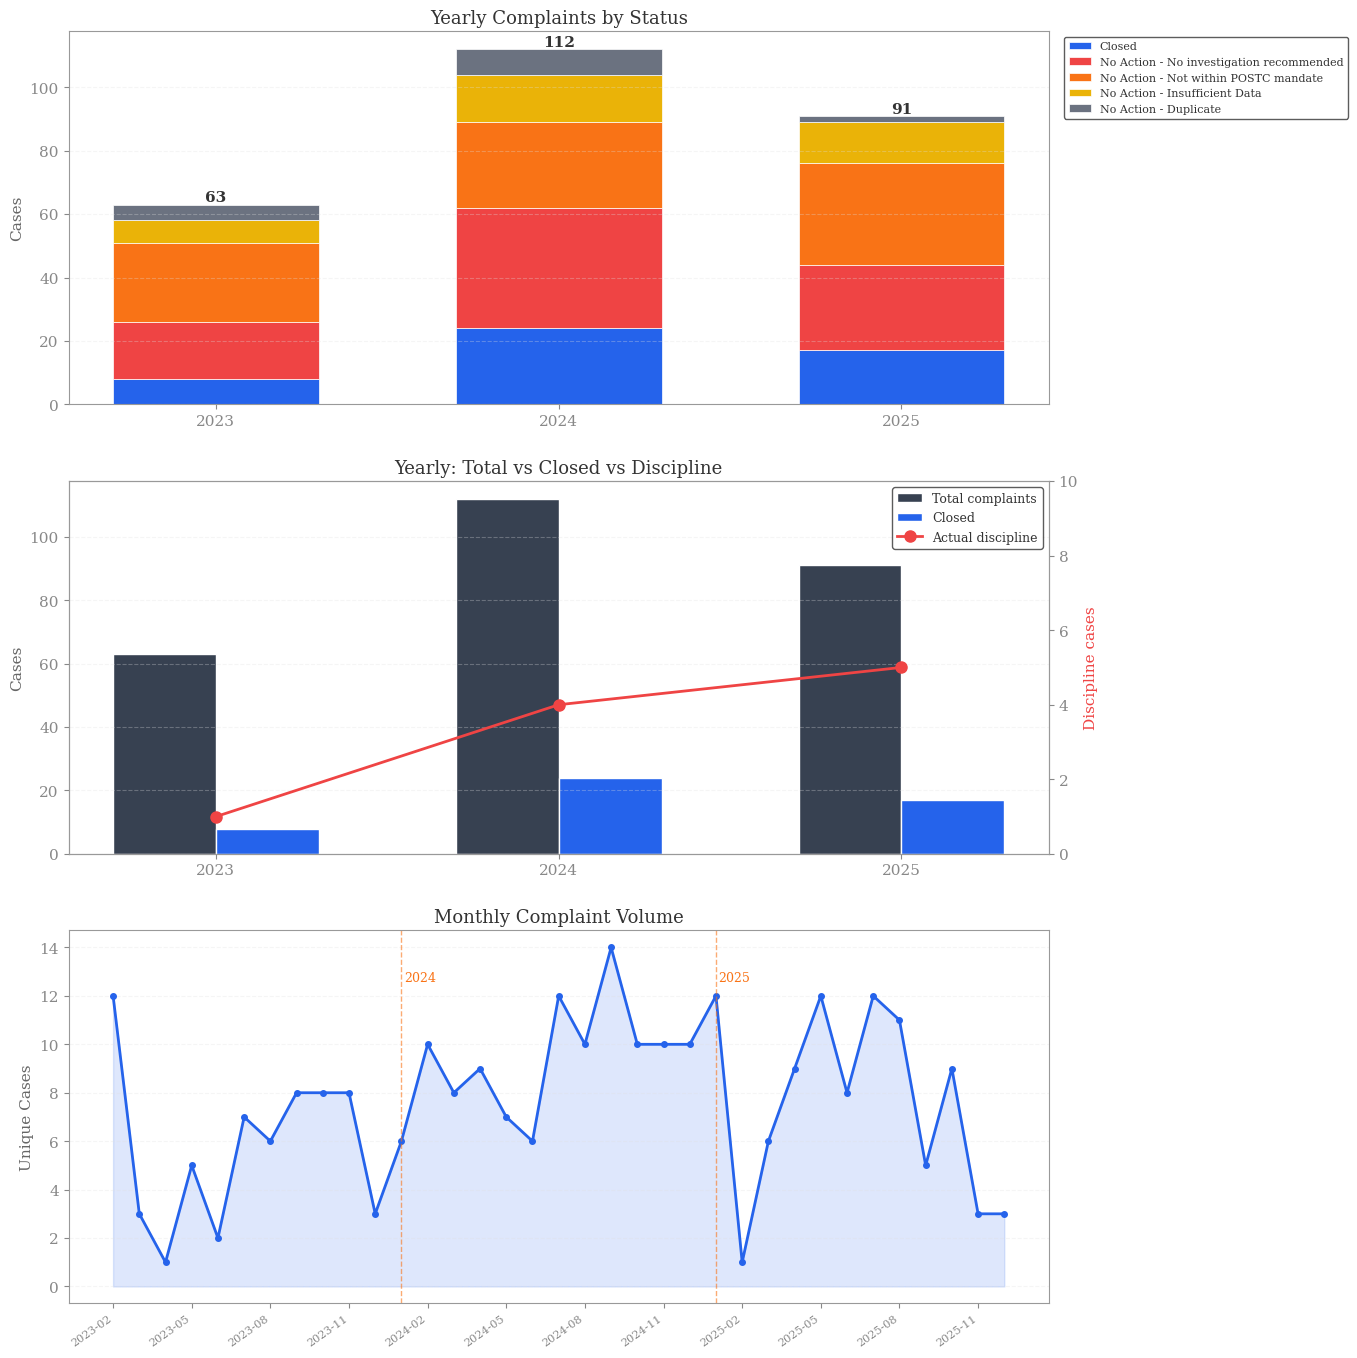

In [26]:
section('TIME TREND')
uc_dated = unique_cases.copy()
uc_dated['year']  = uc_dated['CREATEDDATE'].dt.year
uc_dated['month'] = uc_dated['CREATEDDATE'].dt.to_period('M')

yearly_status = pd.crosstab(uc_dated['year'], uc_dated['STATUS'])
print(yearly_status.to_string())

# yearly discipline
uc_dated['has_discipline'] = (
    uc_dated['Discipline'].notna() &
    ~uc_dated['Discipline'].isin(['No Discipline Imposed','Not Applicable'])
)
yearly_disc = uc_dated.groupby('year')['has_discipline'].sum()
print('\nYearly actual discipline:')
print(yearly_disc)

monthly = uc_dated.groupby('month').size()
monthly_idx = [str(m) for m in monthly.index]

fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.patch.set_facecolor('white')

# ① stacked bar by year — use arange for proper centering
years = yearly_status.index.tolist()
x_yr  = np.arange(len(years))

ax = axes[0]; ax.set_facecolor('white')
bottoms = np.zeros(len(years))
for col in PALETTE:
    if col in yearly_status.columns:
        vals = yearly_status[col].values
        ax.bar(x_yr, vals, bottom=bottoms, label=col,
               color=PALETTE[col], edgecolor='white', linewidth=0.5, width=0.6)
        bottoms += vals
for xi, total_yr in zip(x_yr, bottoms):
    ax.text(xi, total_yr + 1, str(int(total_yr)), ha='center', color='#333', fontsize=11, fontweight='bold')
ax.set_xticks(x_yr)
ax.set_xticklabels([str(y) for y in years])
ax.set_title('Yearly Complaints by Status', color='#333', fontsize=13)
ax.set_ylabel('Cases', color='#666')
ax.legend(fontsize=8, facecolor='white', edgecolor='#333', labelcolor='#333',
          loc='upper left', bbox_to_anchor=(1.01, 1))
ax.grid(axis='y', alpha=0.3); ax.tick_params(colors='#888')

# ② grouped bar — fix position so bars are properly side-by-side
ax2 = axes[1]; ax2.set_facecolor('white')
yearly_total  = uc_dated['year'].value_counts().sort_index()
closed_yearly = uc_dated[uc_dated['STATUS']=='Closed']['year'].value_counts().sort_index()

w = 0.3
ax2.bar(x_yr - w/2, yearly_total.values,
        w, label='Total complaints', color='#374151', edgecolor='white')
ax2.bar(x_yr + w/2, closed_yearly.reindex(years, fill_value=0).values,
        w, label='Closed', color='#2563eb', edgecolor='white')

ax2b = ax2.twinx()
ax2b.set_facecolor('white')
ax2b.plot(x_yr, yearly_disc.reindex(years, fill_value=0).values,
          'o-', color='#ef4444', linewidth=2, markersize=8, label='Actual discipline')
ax2b.set_ylabel('Discipline cases', color='#ef4444'); ax2b.tick_params(colors='#888')
ax2b.set_ylim(0, 10)

ax2.set_xticks(x_yr)
ax2.set_xticklabels([str(y) for y in years])
ax2.set_title('Yearly: Total vs Closed vs Discipline', color='#333', fontsize=13)
ax2.set_ylabel('Cases', color='#666')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=9,
           facecolor='white', edgecolor='#333', labelcolor='#333')
ax2.grid(axis='y', alpha=0.3); ax2.tick_params(colors='#888')

# ③ monthly line
ax3 = axes[2]; ax3.set_facecolor('white')
ax3.plot(monthly_idx, monthly.values, 'o-',
         color='#2563eb', linewidth=2, markersize=4, label='Monthly complaints')
ax3.fill_between(monthly_idx, monthly.values, alpha=0.15, color='#2563eb')

for yr in [2024, 2025]:
    boundary = f'{yr}-01'
    if boundary in monthly_idx:
        ax3.axvline(monthly_idx.index(boundary), color='#f97316',
                    linestyle='--', linewidth=1, alpha=0.6)
        ax3.text(monthly_idx.index(boundary) + 0.1, monthly.max() * 0.9,
                 str(yr), color='#f97316', fontsize=9)

ax3.set_xticks(range(0, len(monthly_idx), 3))
ax3.set_xticklabels([monthly_idx[i] for i in range(0, len(monthly_idx), 3)],
                    rotation=35, ha='right', fontsize=8)
ax3.set_title('Monthly Complaint Volume', color='#333', fontsize=13)
ax3.set_ylabel('Unique Cases', color='#666')
ax3.grid(axis='y', alpha=0.3); ax3.tick_params(colors='#888')

plt.tight_layout(pad=2)
plt.show()

## 12. Agency-Level Summary


  AGENCY-LEVEL SUMMARY
Top 15 agencies by complaint count:
   13  Massachusetts State Police
    9  Boston Police Department
    7  Lowell Police Department
    6  Billerica Police Department
    5  Gardner Police Department
    5  Seekonk Police Department
    5  Salem Police Department
    5  Brockton Police Department
    4  Weymouth Police Department
    4  Revere Police Department
    4  Plymouth Police Department
    4  Ayer Police Department
    3  Douglas Police Department
    3  Orange Police Department
    3  Millbury Police Department


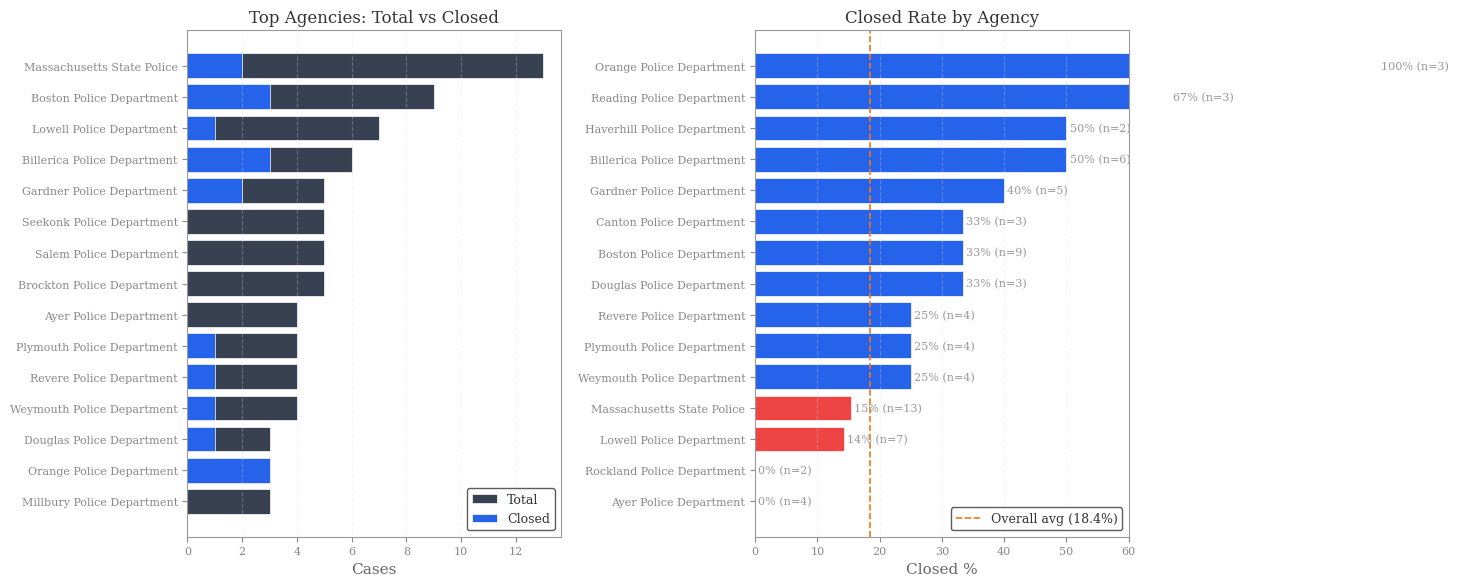

In [14]:
section('AGENCY-LEVEL SUMMARY')
agency_counts  = unique_cases['REPORTINGAGENCY'].value_counts(dropna=True).head(15)
closed_cases   = unique_cases[unique_cases['STATUS']=='Closed']
closed_agency  = closed_cases['REPORTINGAGENCY'].value_counts(dropna=True)

print('Top 15 agencies by complaint count:')
for agency, cnt in agency_counts.items(): print(f'  {cnt:>3}  {agency}')

# compute closed rate per agency (min 3 cases)
agency_summary = []
for agency in unique_cases['REPORTINGAGENCY'].value_counts().head(20).index:
    sub = unique_cases[unique_cases['REPORTINGAGENCY']==agency]
    if len(sub) < 2: continue
    closed_r = (sub['STATUS']=='Closed').sum() / len(sub) * 100
    agency_summary.append({'Agency': agency, 'Total': len(sub), 'Closed': (sub['STATUS']=='Closed').sum(), 'Closed%': closed_r})
as_df = pd.DataFrame(agency_summary).sort_values('Total', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

ax1.set_facecolor('white')
top15 = as_df.head(15)
ax1.barh(top15['Agency'][::-1], top15['Total'][::-1],
         color='#374151', edgecolor='white', linewidth=0.5, label='Total')
ax1.barh(top15['Agency'][::-1], top15['Closed'][::-1],
         color='#2563eb', edgecolor='white', linewidth=0.5, label='Closed')
ax1.set_xlabel('Cases', color='#666')
ax1.set_title('Top Agencies: Total vs Closed', color='#333', fontsize=12)
ax1.legend(fontsize=9, facecolor='white', edgecolor='#333', labelcolor='#333')
ax1.grid(axis='x', alpha=0.3); ax1.tick_params(colors='#888', labelsize=8)

ax2.set_facecolor('white')
sorted_cr = as_df.sort_values('Closed%', ascending=True).tail(15)
clrs = ['#2563eb' if v >= closed_n/total_cases*100 else '#ef4444' for v in sorted_cr['Closed%']]
ax2.barh(sorted_cr['Agency'], sorted_cr['Closed%'],
         color=clrs, edgecolor='white', linewidth=0.5)
ax2.axvline(closed_n/total_cases*100, color='#f97316',
            linestyle='--', linewidth=1.2, label=f'Overall avg ({closed_n/total_cases:.1%})')
for i, (_, row) in enumerate(sorted_cr.iterrows()):
    ax2.text(row['Closed%']+0.5, i, f"{row['Closed%']:.0f}% (n={row['Total']})",
             va='center', color='#999', fontsize=8)
ax2.set_xlabel('Closed %', color='#666')
ax2.set_title('Closed Rate by Agency', color='#333', fontsize=12)
ax2.set_xlim(0, 60)
ax2.legend(fontsize=9, facecolor='white', edgecolor='#333', labelcolor='#333')
ax2.grid(axis='x', alpha=0.3); ax2.tick_params(colors='#888', labelsize=8)

plt.tight_layout()
plt.show()

## 13. SRO / School Officers


  SRO / SCHOOL-AFFILIATED OFFICERS
  SRO/school cases: 19 / 266
    No Action - No investigation recommended: 7 (36.8%)
    Closed: 5 (26.3%)
    No Action - Not within POSTC mandate: 3 (15.8%)
    No Action - Insufficient Data: 2 (10.5%)
    No Action - Duplicate: 2 (10.5%)


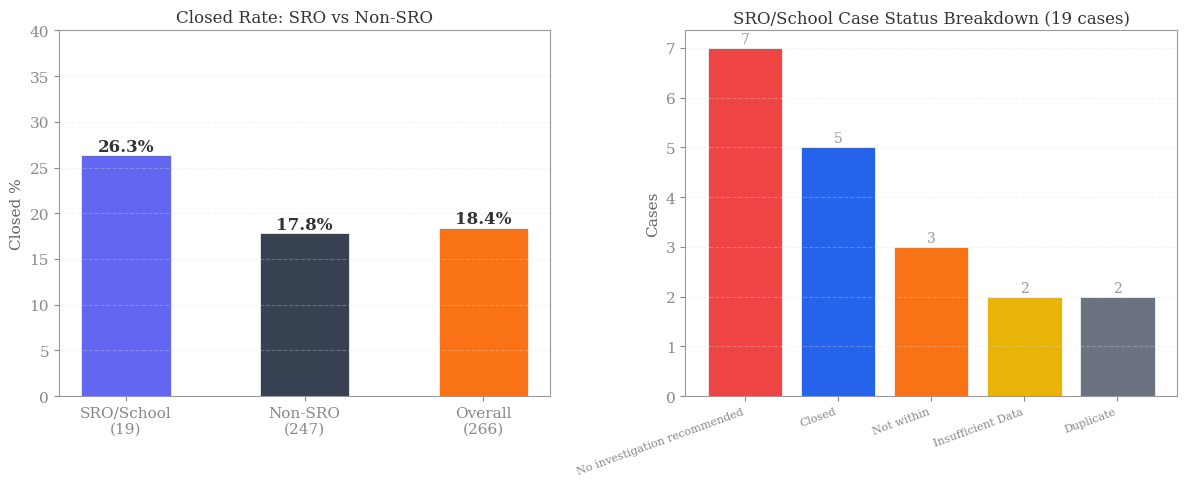

In [19]:
section('SRO / SCHOOL-AFFILIATED OFFICERS')
school_agencies = ['Bridgewater State University','Western New England University',
                   'Stonehill College','Mount Holyoke College']
sro_mask = (
    df['TITLE'].str.contains('SRO', case=False, na=False) |
    df['REPORTINGAGENCY'].isin(school_agencies) |
    df['CERTIFICATIONSTATUS'].str.contains('SRO', case=False, na=False)
)
sro_cases_idx = df[sro_mask]['COMPLAINTNUMBER'].unique()
sro_sub       = unique_cases[unique_cases['COMPLAINTNUMBER'].isin(sro_cases_idx)]
non_sro_sub   = unique_cases[~unique_cases['COMPLAINTNUMBER'].isin(sro_cases_idx)]

print(f'  SRO/school cases: {len(sro_sub)} / {total_cases}')
for k,v in sro_sub['STATUS'].value_counts().items():
    print(f'    {k}: {pct(v, len(sro_sub))}')

# compare sro vs non-sro closed rate
sro_closed     = (sro_sub['STATUS']=='Closed').sum() / len(sro_sub) * 100
non_sro_closed = (non_sro_sub['STATUS']=='Closed').sum() / len(non_sro_sub) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('white')

ax1.set_facecolor('white')
compare = {'SRO/School\n(19)': sro_closed, 'Non-SRO\n(247)': non_sro_closed, 'Overall\n(266)': closed_n/total_cases*100}
bars = ax1.bar(compare.keys(), compare.values(),
               color=['#6366f1','#374151','#f97316'],
               edgecolor='white', linewidth=0.5, width=0.5)
for bar, v in zip(bars, compare.values()):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{v:.1f}%', ha='center', color='#333', fontsize=12, fontweight='bold')
ax1.set_title('Closed Rate: SRO vs Non-SRO', color='#333', fontsize=12)
ax1.set_ylabel('Closed %', color='#666')
ax1.set_ylim(0, 40)
ax1.grid(axis='y', alpha=0.3); ax1.tick_params(colors='#888')

ax2.set_facecolor('white')
sro_status = sro_sub['STATUS'].value_counts()
clrs2 = [PALETTE.get(k,'#555') for k in sro_status.index]
bars2 = ax2.bar(range(len(sro_status)), sro_status.values,
                color=clrs2, edgecolor='white', linewidth=0.5)
ax2.set_xticks(range(len(sro_status)))
short_labels = [s.replace('No Action - ','').replace(' POSTC mandate','') for s in sro_status.index]
ax2.set_xticklabels(short_labels, rotation=20, ha='right', fontsize=8)
for bar, v in zip(bars2, sro_status.values):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             str(v), ha='center', color='#999', fontsize=10)
ax2.set_title('SRO/School Case Status Breakdown (19 cases)', color='#333', fontsize=12)
ax2.set_ylabel('Cases', color='#666')
ax2.grid(axis='y', alpha=0.3); ax2.tick_params(colors='#888')

plt.tight_layout()
plt.show()

## 14. Complaint Type & Internal Incident


  COMPLAINT TYPE
  Public Complaint: 260 (97.7%)
  Internal Incident: 4 (1.5%)
  nan: 2 (0.8%)

Internal Incident cases:
 COMPLAINTNUMBER                REPORTINGAGENCY STATUS                    Discipline
          7870.0          Mount Holyoke College Closed  Written Reprimand,Retraining
         10254.0 Western New England University Closed Suspension, 1-5 days,Demotion
         10298.0    Cambridge Police Department Closed                       Pending
         11198.0              Stonehill College Closed        Termination or similar


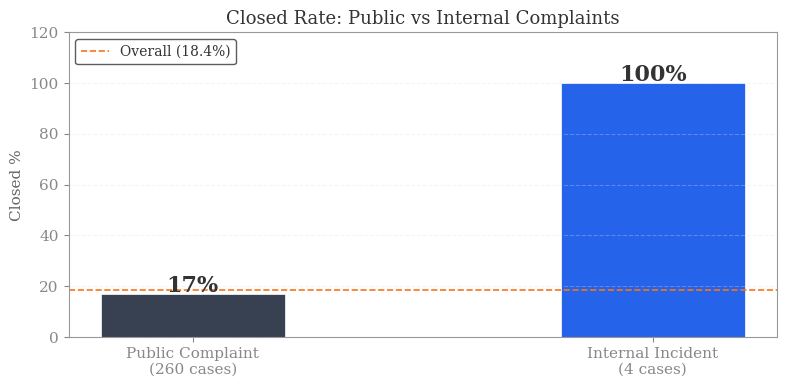

In [16]:
section('COMPLAINT TYPE')
ct = unique_cases['Complaint Type (Complaint)'].value_counts(dropna=False)
for k,v in ct.items(): print(f'  {k}: {pct(v, total_cases)}')

internal = unique_cases[unique_cases['Complaint Type (Complaint)']=='Internal Incident']
print('\nInternal Incident cases:')
print(internal[['COMPLAINTNUMBER','REPORTINGAGENCY','STATUS','Discipline']].to_string(index=False))

# comparison chart
public_closed   = (unique_cases[unique_cases['Complaint Type (Complaint)']=='Public Complaint']['STATUS']=='Closed').sum()
public_total    = (unique_cases['Complaint Type (Complaint)']=='Public Complaint').sum()
internal_closed = (internal['STATUS']=='Closed').sum()

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')

categories = ['Public Complaint\n(260 cases)', 'Internal Incident\n(4 cases)']
closed_rates = [public_closed/public_total*100, internal_closed/len(internal)*100]
bars = ax.bar(categories, closed_rates, color=['#374151','#2563eb'],
              edgecolor='white', linewidth=0.5, width=0.4)
for bar, v in zip(bars, closed_rates):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{v:.0f}%', ha='center', color='#333', fontsize=16, fontweight='bold')
ax.axhline(closed_n/total_cases*100, color='#f97316',
           linestyle='--', linewidth=1.2, label=f'Overall ({closed_n/total_cases:.1%})')
ax.set_ylabel('Closed %', color='#666')
ax.set_title('Closed Rate: Public vs Internal Complaints', color='#333', fontsize=13)
ax.set_ylim(0, 120)
ax.legend(fontsize=10, facecolor='white', edgecolor='#333', labelcolor='#333')
ax.grid(axis='y', alpha=0.3); ax.tick_params(colors='#888')
plt.tight_layout()
plt.show()


## 15. Key Insights Summary


  KEY INSIGHTS SUMMARY SCORECARD
Metric                                 Count   / Total         %
-----------------------------------------------------------------
  Unique complaints                      266  / 266        100.0%
  Unique officers                        290  / 290        100.0%
  Certified (by case)                    175  / 266         65.8%
  Certified/SRO (by case)                 11  / 266          4.1%
  No Action — any                        217  / 266         81.6%
  Closed                                  49  / 266         18.4%
  Actual discipline                       10  / 266          3.8%
  Multi-officer cases                     56  / 266         21.1%
  Discrimination claims                   37  / 266         13.9%
  LEA Sustained finding                   16  / 266          6.0%
  Internal Incident → Closed               4  / 4          100.0%
  Excessive Force → Closed                 3  / 27          11.1%


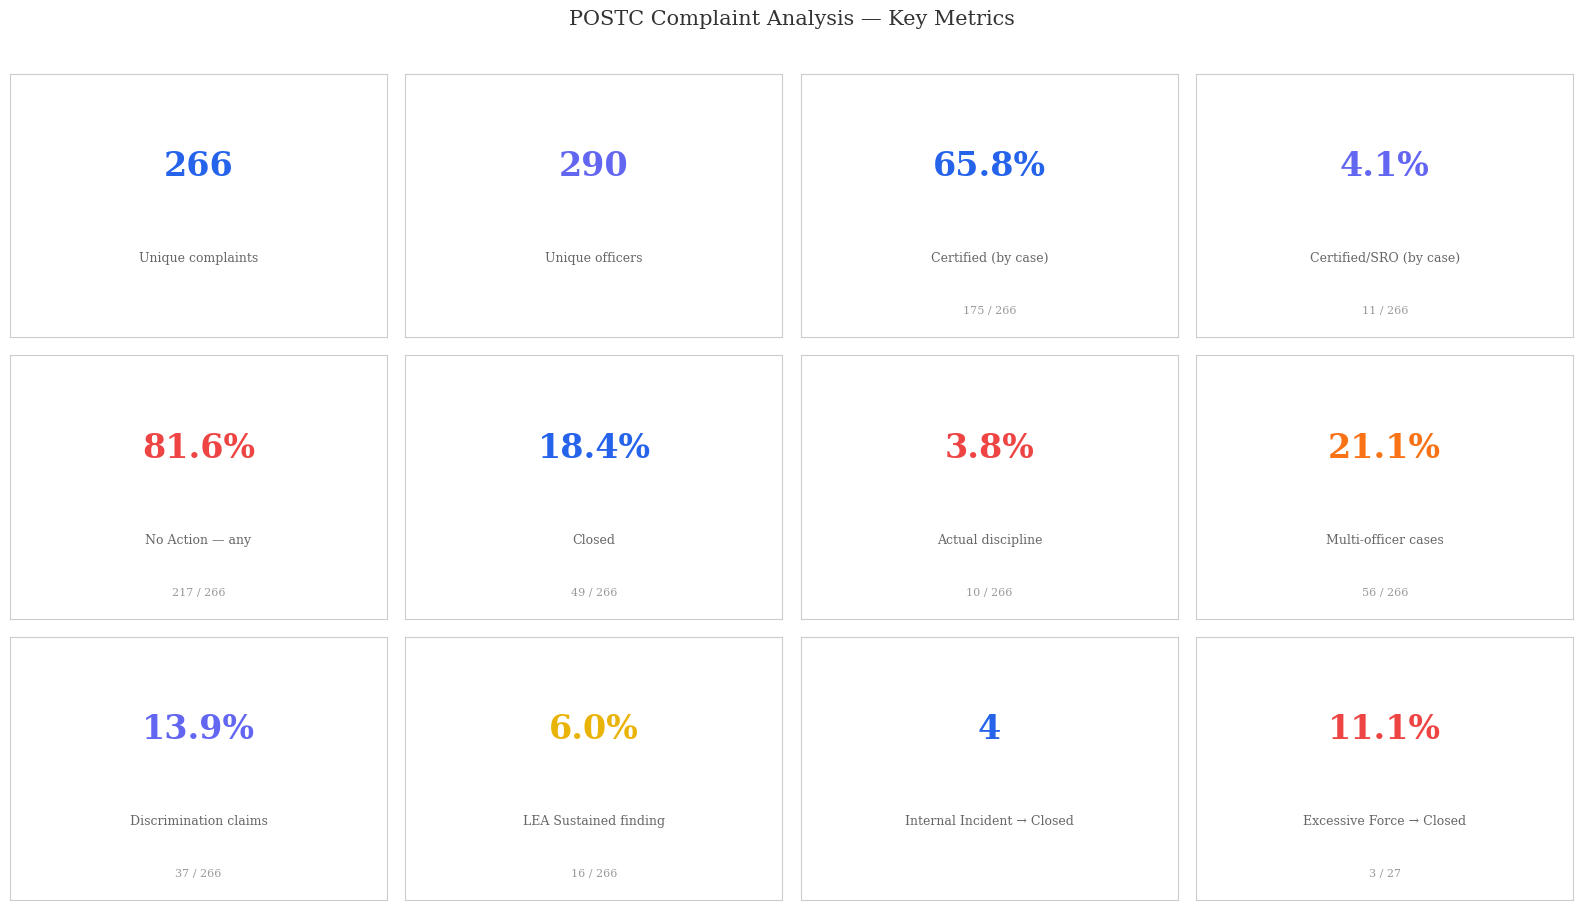


────────────────────────────────────────────────────────────
TOP FINDINGS
────────────────────────────────────────────────────────────
  1. 81.6% of complaints closed as No Action without investigation
  2. Only 10 out of 266 cases resulted in actual discipline (3.8%)
  3. Internal incidents: 100% discipline vs. public complaints: 3.8%
  4. POSTC closes cases only when LEA already found Sustained — no independent findings
  5. Discrimination claims have a lower Closed rate (13.5%) vs. overall average (18.4%)
  6. Excessive Force: only 3 of 27 cases Closed (11.1%) — below average
  7. Complaints surged 78% from 2023 to 2024 (63 → 112 cases)
  8. Restricted/Decertified officer cases → 100% Closed


In [17]:
section('KEY INSIGHTS SUMMARY SCORECARD')

cert_n     = (unique_cases['CERTIFICATIONSTATUS']=='Certified').sum()
cert_sro_n = (unique_cases['CERTIFICATIONSTATUS']=='Certified/SRO').sum()
disc_cases_n = len(df[df['any_discrimination']==1]['COMPLAINTNUMBER'].unique())
lea_sus_n    = len(unique_cases[unique_cases['LEA Disposition (Allegations)'].astype(str).str.contains('Sustained', na=False)])
multi_n      = len(officer_per_case[officer_per_case > 1])

metrics = [
    ('Unique complaints',              total_cases,                  total_cases,  '#2563eb'),
    ('Unique officers',                total_officers,               total_officers,'#6366f1'),
    ('Certified (by case)',            cert_n,                       total_cases,  '#2563eb'),
    ('Certified/SRO (by case)',        cert_sro_n,                   total_cases,  '#6366f1'),
    ('No Action — any',                no_action_n,                  total_cases,  '#ef4444'),
    ('Closed',                         closed_n,                     total_cases,  '#2563eb'),
    ('Actual discipline',              len(actual_disc),             total_cases,  '#ef4444'),
    ('Multi-officer cases',            multi_n,                      total_cases,  '#f97316'),
    ('Discrimination claims',          disc_cases_n,                 total_cases,  '#6366f1'),
    ('LEA Sustained finding',          lea_sus_n,                    total_cases,  '#eab308'),
    ('Internal Incident → Closed',     int(internal_closed),         len(internal),'#2563eb'),
    ('Excessive Force → Closed',       3,                            27,           '#ef4444'),
]

print(f"{'Metric':<35} {'Count':>8}  {'/ Total':>8}  {'%':>8}")
print('-'*65)
for label, n, denom, _ in metrics:
    print(f"  {label:<33} {n:>8}  / {denom:<8}  {n/denom:>7.1%}")

# visual scorecard
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
fig.patch.set_facecolor('white')
fig.suptitle('POSTC Complaint Analysis — Key Metrics', color='#333', fontsize=15, y=1.01)

for ax, (label, n, denom, color) in zip(axes.flat, metrics):
    ax.set_facecolor('white')
    for spine in ax.spines.values(): spine.set_edgecolor('#ccc')
    ax.set_xticks([]); ax.set_yticks([])
    val_str = f'{n/denom:.1%}' if denom != n else str(n)
    ax.text(0.5, 0.65, val_str,  ha='center', va='center', fontsize=24, fontweight='bold',
            color=color, transform=ax.transAxes)
    ax.text(0.5, 0.30, label,    ha='center', va='center', fontsize=9, color='#666',
            transform=ax.transAxes, wrap=True)
    if denom != n:
        ax.text(0.5, 0.10, f'{n} / {denom}', ha='center', va='center', fontsize=8,
                color='#999', transform=ax.transAxes)

plt.tight_layout(pad=1.2)
plt.show()

print()
print('─'*60)
print('TOP FINDINGS')
print('─'*60)
findings = [
    '1. 81.6% of complaints closed as No Action without investigation',
    '2. Only 10 out of 266 cases resulted in actual discipline (3.8%)',
    '3. Internal incidents: 100% discipline vs. public complaints: 3.8%',
    '4. POSTC closes cases only when LEA already found Sustained — no independent findings',
    '5. Discrimination claims have a lower Closed rate (13.5%) vs. overall average (18.4%)',
    '6. Excessive Force: only 3 of 27 cases Closed (11.1%) — below average',
    '7. Complaints surged 78% from 2023 to 2024 (63 → 112 cases)',
    '8. Restricted/Decertified officer cases → 100% Closed',
]
for f in findings: print(f'  {f}')

In [18]:
cross_disc = pd.crosstab(
    unique_cases['STATUS'],
    unique_cases['Discipline'].apply(lambda d:
        'No entry' if pd.isna(d) else
        'No Discipline' if d in ['No Discipline Imposed', 'Not Applicable'] else
        'Actual Discipline'
    ),
    margins=True
)
print(cross_disc.to_string())

Discipline                                Actual Discipline  No Discipline  No entry  All
STATUS                                                                                   
Closed                                                   10             22        17   49
No Action - Duplicate                                     0              0        15   15
No Action - Insufficient Data                             0              0        35   35
No Action - No investigation recommended                  0              3        80   83
No Action - Not within POSTC mandate                      0              0        84   84
All                                                      10             25       231  266



  LEA DISPOSITION × POSTC DISPOSITION × STATUS
Has LEA disposition : 31 cases
No  LEA disposition : 235 cases

LEA disposition breakdown:
  Sustained (mixed): 12
  Exonerated: 9
  Sustained: 4
  Unfounded: 4
  Exonerated (mixed): 2

POSTC disposition breakdown:
  (No POSTC disposition): 236
  Accept LEA Disposition: 28
  Investigated as Part of a PI: 2

Full flow (has LEA):
  LEA=Sustained (mixed)              POSTC=Accept LEA Disposition              STATUS=Closed  n=10
  LEA=Exonerated                     POSTC=Accept LEA Disposition              STATUS=Closed  n=7
  LEA=Unfounded                      POSTC=Accept LEA Disposition              STATUS=Closed  n=4
  LEA=Sustained                      POSTC=Accept LEA Disposition              STATUS=Closed  n=3
  LEA=Exonerated                     POSTC=Accept LEA Disposition              STATUS=No Action - No investigation recommended  n=2
  LEA=Exonerated (mixed)             POSTC=Accept LEA Disposition              STATUS=Closed  n=2

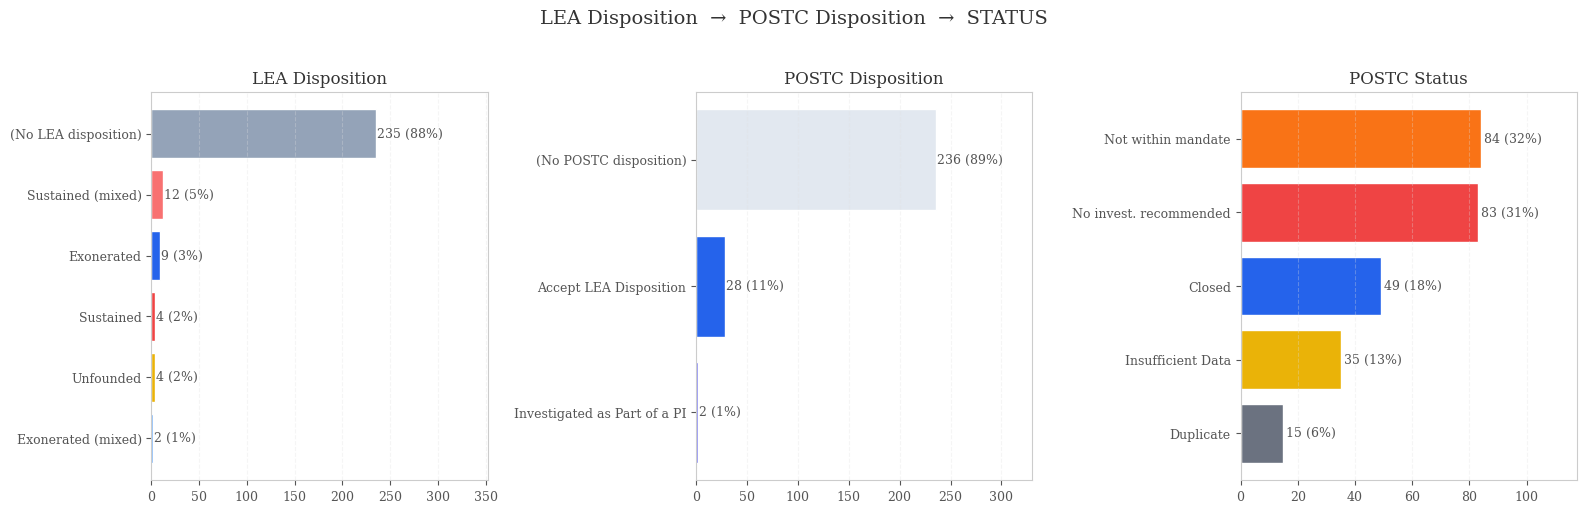

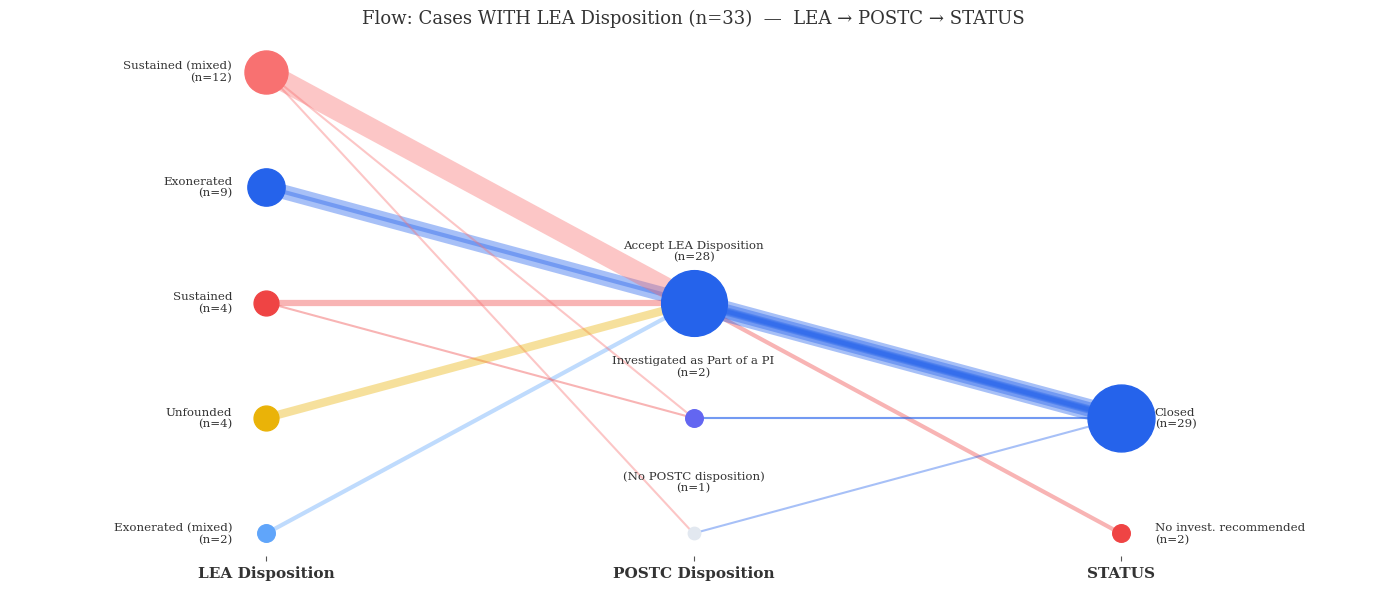

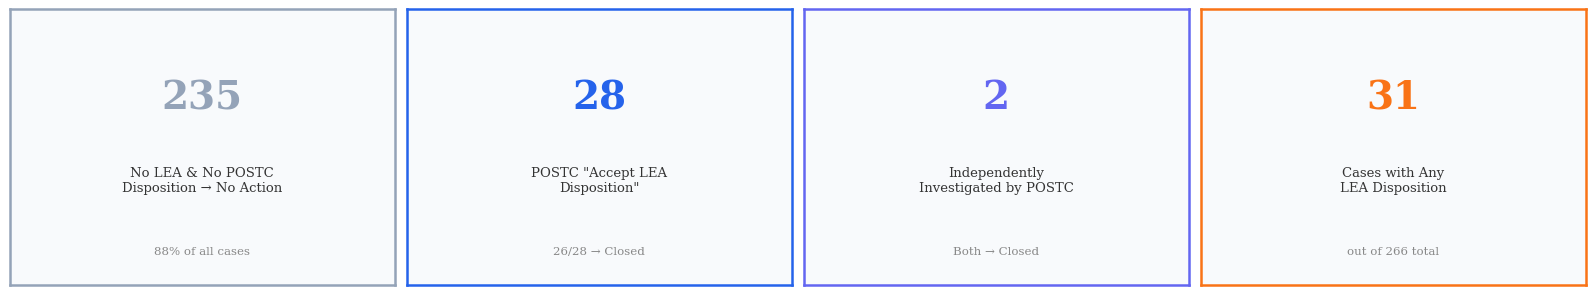

In [29]:
section('LEA DISPOSITION × POSTC DISPOSITION × STATUS')

# ── prep ───────────────────────────────────────────────────────────
def norm_lea(val):
    v = str(val).strip()
    if v in ('0', '', 'nan'): return None
    if 'Sustained' in v and len(v.replace('Sustained','').strip(',')) == 0:
        return 'Sustained'
    if 'Sustained' in v: return 'Sustained (mixed)'
    if v == 'Exonerated': return 'Exonerated'
    if 'Exonerated' in v: return 'Exonerated (mixed)'
    if v == 'Not Sustained': return 'Not Sustained'
    if v == 'Unfounded': return 'Unfounded'
    if 'Unfounded' in v: return 'Unfounded (mixed)'
    return v

def norm_postc(val):
    v = str(val).strip()
    if v in ('0', '', 'nan'): return '(No POSTC disposition)'
    return v

uc = unique_cases.copy()
uc['lea']   = uc['LEA Disposition (Allegations)'].apply(norm_lea)
uc['postc'] = uc['POSTC Disposition (Allegations)'].apply(norm_postc)

has_lea  = uc[uc['lea'].notna()]
no_lea   = uc[uc['lea'].isna()]

print(f"Has LEA disposition : {len(has_lea)} cases")
print(f"No  LEA disposition : {len(no_lea)} cases")
print(f"\nLEA disposition breakdown:")
for k,v in has_lea['lea'].value_counts().items():
    print(f"  {k}: {v}")
print(f"\nPOSTC disposition breakdown:")
for k,v in uc['postc'].value_counts().items():
    print(f"  {k}: {v}")
print(f"\nFull flow (has LEA):")
for _, r in has_lea[['lea','postc','STATUS']].value_counts().reset_index().iterrows():
    print(f"  LEA={r['lea']:30} POSTC={r['postc']:35} STATUS={r['STATUS']}  n={r['count']}")

# ── colour maps ─────────────────────────────────────────────────────
LEA_COLORS = {
    'Sustained':           '#ef4444',
    'Sustained (mixed)':   '#f87171',
    'Exonerated':          '#2563eb',
    'Exonerated (mixed)':  '#60a5fa',
    'Not Sustained':       '#f97316',
    'Unfounded':           '#eab308',
    'Unfounded (mixed)':   '#fde047',
}
POSTC_COLORS = {
    'Accept LEA Disposition':        '#2563eb',
    'Investigated as Part of a PI':  '#6366f1',
    '(No POSTC disposition)':        '#e2e8f0',
}

# ── Figure 1: three-column distribution overview ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('white')
fig.suptitle('LEA Disposition  →  POSTC Disposition  →  STATUS', color='#333', fontsize=14, y=1.02)

# Panel 1: LEA
ax = axes[0]; ax.set_facecolor('white')
lea_vals = uc['lea'].fillna('(No LEA disposition)').value_counts()
colors_lea = [LEA_COLORS.get(k, '#94a3b8') for k in lea_vals.index]
bars = ax.barh(lea_vals.index[::-1], lea_vals.values[::-1], color=colors_lea[::-1], edgecolor='white')
for bar, v in zip(bars, lea_vals.values[::-1]):
    ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
            f'{v} ({v/total_cases:.0%})', va='center', color='#555', fontsize=9)
ax.set_title('LEA Disposition', color='#333', fontsize=12)
ax.set_xlim(0, lea_vals.max()*1.5)
ax.grid(axis='x', alpha=0.3); ax.tick_params(colors='#555', labelsize=9)
for s in ax.spines.values(): s.set_edgecolor('#ccc')

# Panel 2: POSTC
ax = axes[1]; ax.set_facecolor('white')
postc_vals = uc['postc'].value_counts()
colors_postc = [POSTC_COLORS.get(k,'#94a3b8') for k in postc_vals.index]
bars = ax.barh(postc_vals.index[::-1], postc_vals.values[::-1], color=colors_postc[::-1], edgecolor='white')
for bar, v in zip(bars, postc_vals.values[::-1]):
    ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
            f'{v} ({v/total_cases:.0%})', va='center', color='#555', fontsize=9)
ax.set_title('POSTC Disposition', color='#333', fontsize=12)
ax.set_xlim(0, postc_vals.max()*1.4)
ax.grid(axis='x', alpha=0.3); ax.tick_params(colors='#555', labelsize=9)
for s in ax.spines.values(): s.set_edgecolor('#ccc')

# Panel 3: STATUS
ax = axes[2]; ax.set_facecolor('white')
status_vals = uc['STATUS'].value_counts()
short = {
    'Closed': 'Closed',
    'No Action - No investigation recommended': 'No invest. recommended',
    'No Action - Not within POSTC mandate':     'Not within mandate',
    'No Action - Insufficient Data':            'Insufficient Data',
    'No Action - Duplicate':                    'Duplicate',
}
bars = ax.barh([short.get(k,k) for k in status_vals.index[::-1]],
               status_vals.values[::-1],
               color=[PALETTE.get(k,'#94a3b8') for k in status_vals.index[::-1]],
               edgecolor='white')
for bar, v in zip(bars, status_vals.values[::-1]):
    ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
            f'{v} ({v/total_cases:.0%})', va='center', color='#555', fontsize=9)
ax.set_title('POSTC Status', color='#333', fontsize=12)
ax.set_xlim(0, status_vals.max()*1.4)
ax.grid(axis='x', alpha=0.3); ax.tick_params(colors='#555', labelsize=9)
for s in ax.spines.values(): s.set_edgecolor('#ccc')

plt.tight_layout()
plt.show()

# ── Figure 2: flow — has LEA disposition (33 cases) ────────────────
flow = has_lea.groupby(['lea','postc','STATUS']).size().reset_index(name='n')

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')
fig.suptitle('Flow: Cases WITH LEA Disposition (n=33)  —  LEA → POSTC → STATUS',
             color='#333', fontsize=13)

lea_cats   = has_lea['lea'].value_counts().index.tolist()
postc_cats = [c for c in ['Accept LEA Disposition','Investigated as Part of a PI','(No POSTC disposition)']
              if c in has_lea['postc'].values]
status_cats = list(PALETTE.keys())

x_lea, x_postc, x_status = 0, 1, 2
y_lea   = {c: i for i, c in enumerate(lea_cats[::-1])}
y_postc = {c: i for i, c in enumerate(postc_cats[::-1])}
y_status= {c: i for i, c in enumerate([k for k in status_cats if k in has_lea['STATUS'].values][::-1])}

# scatter nodes
for c, yi in y_lea.items():
    n = (has_lea['lea'] == c).sum()
    ax.scatter(x_lea, yi, s=n*80, color=LEA_COLORS.get(c,'#94a3b8'), zorder=3)
    ax.text(x_lea-0.08, yi, f'{c}\n(n={n})', ha='right', va='center', fontsize=8.5, color='#333')

for c, yi in y_postc.items():
    n = (has_lea['postc'] == c).sum()
    ax.scatter(x_postc, yi, s=n*80, color=POSTC_COLORS.get(c,'#94a3b8'), zorder=3)
    ax.text(x_postc, yi+0.35, f'{c}\n(n={n})', ha='center', va='bottom', fontsize=8.5, color='#333')

for c, yi in y_status.items():
    n = (has_lea['STATUS'] == c).sum()
    ax.scatter(x_status, yi, s=n*80, color=PALETTE.get(c,'#94a3b8'), zorder=3)
    ax.text(x_status+0.08, yi, f'{short.get(c,c)}\n(n={n})', ha='left', va='center', fontsize=8.5, color='#333')

# draw lines
for _, row in flow.iterrows():
    if row['lea'] in y_lea and row['postc'] in y_postc:
        ax.plot([x_lea, x_postc], [y_lea[row['lea']], y_postc[row['postc']]],
                color=LEA_COLORS.get(row['lea'],'#aaa'), alpha=0.4,
                linewidth=row['n']*1.5)
    if row['postc'] in y_postc and row['STATUS'] in y_status:
        ax.plot([x_postc, x_status], [y_postc[row['postc']], y_status[row['STATUS']]],
                color=PALETTE.get(row['STATUS'],'#aaa'), alpha=0.4,
                linewidth=row['n']*1.5)

ax.set_xlim(-0.6, 2.6)
ax.set_xticks([x_lea, x_postc, x_status])
ax.set_xticklabels(['LEA Disposition', 'POSTC Disposition', 'STATUS'],
                   fontsize=11, color='#333', fontweight='bold')
ax.set_yticks([]); ax.set_ylabel('')
for s in ax.spines.values(): s.set_visible(False)
ax.grid(False)
plt.tight_layout()
plt.show()

# ── Figure 3: callout summary ───────────────────────────────────────
no_both    = ((uc['lea'].isna()) & (uc['postc'] == '(No POSTC disposition)')).sum()
accept_lea = (uc['postc'] == 'Accept LEA Disposition').sum()
accept_closed = ((uc['postc'] == 'Accept LEA Disposition') & (uc['STATUS'] == 'Closed')).sum()
pi_cases   = (uc['postc'] == 'Investigated as Part of a PI').sum()

callouts = [
    (f'{no_both}',       'No LEA & No POSTC\nDisposition → No Action',   f'{no_both/total_cases:.0%} of all cases',    '#94a3b8'),
    (f'{accept_lea}',    'POSTC "Accept LEA\nDisposition"',               f'{accept_closed}/{accept_lea} → Closed',      '#2563eb'),
    (f'{pi_cases}',      'Independently\nInvestigated by POSTC',          'Both → Closed',                               '#6366f1'),
    (f'{len(has_lea)}',  'Cases with Any\nLEA Disposition',               f'out of {total_cases} total',                 '#f97316'),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
fig.patch.set_facecolor('white')
for ax, (val, label, sub, color) in zip(axes, callouts):
    ax.set_facecolor('#f8fafc')
    for s in ax.spines.values(): s.set_edgecolor(color); s.set_linewidth(1.8)
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.5, 0.68, val,   ha='center', va='center', fontsize=28, fontweight='bold',
            color=color, transform=ax.transAxes)
    ax.text(0.5, 0.38, label, ha='center', va='center', fontsize=9.5, color='#333',
            transform=ax.transAxes)
    ax.text(0.5, 0.12, sub,   ha='center', va='center', fontsize=8.5, color='#888',
            transform=ax.transAxes)
plt.tight_layout(pad=0.8)
plt.show()